# **Práctica 4: Sensado de señales fisiológicas**

### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos

*Estudiante: Cielo Aholiva Higuera Gutiérrez*

En esta práctica, se propone recopilar datos fisiológicos en un entorno de realidad virtual donde los participantes caminan sobre una tabla a gran altura mientras usan el sensor de ritmo cardíaco Polar H10. El objetivo principal del notebook es desarrollar un clasificador que analice los cambios en la frecuencia cardíaca dentro del entorno virtual y evalúe la experiencia del participante a través de un nivel de miedo.

La información recopilada permitirá analizar la respuesta fisiologica del estudiante en cada evento del entorno virtual y se desarrollará un modelo que pueda identificar el contexto del entorno.

#### **Dataset**

El conjunto de datos se generó a partir de la captura de la variabilidad de la frecuencia cardíaca (HRV) de los participantes mientras interactuaban en el entorno de realidad virtual. La HRV fue medida mediante un sensor colocado en el esternón, el cual registró las señales eléctricas del corazón.

La anotación del conjunto de datos se realizó mediante la revisión de los videos de los participantes en la experiencia virtual. Se identificaron manualmente los distintos contextos dentro del entorno y se etiquetaron los segmentos correspondientes en cada video.

Importar librerias

In [3]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.5 MB/s eta 0:00:00


In [49]:
pip install kubios --quiet

In [50]:
# system libraries
import os
import sys
import re

# data
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import kubios

# model
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.validation import check_array
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from catboost import CatBoostClassifier

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Análisis exploratorio**

En esta sección se llevó a cabo un análisis exploratorio de las señales de variabilidad de la frecuencia cardíaca (HRV) registradas durante la interacción en el entorno de realidad virtual. La HRV se define como la variación en los intervalos entre latidos cardíacos y se expresa en milisegundos.

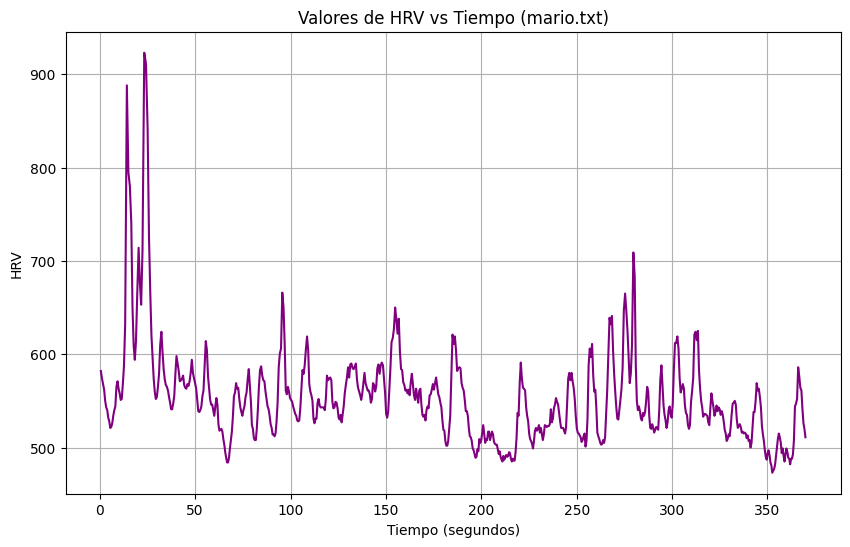

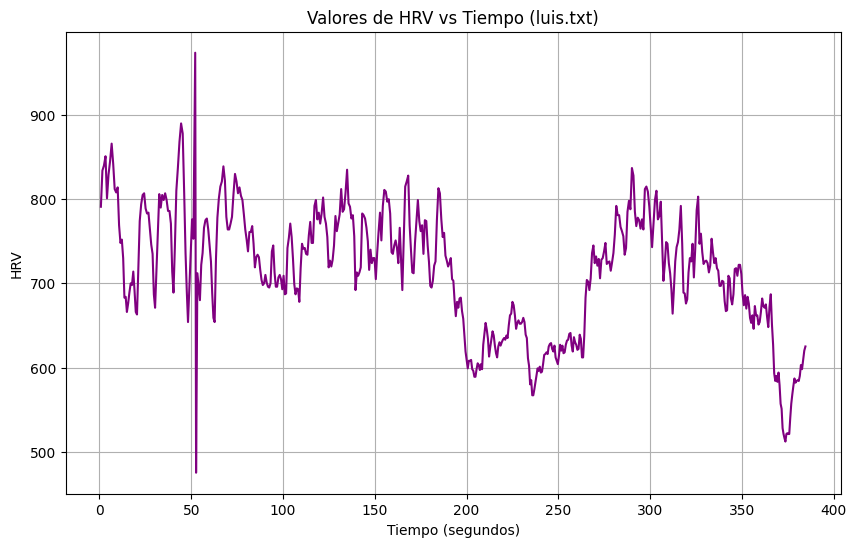

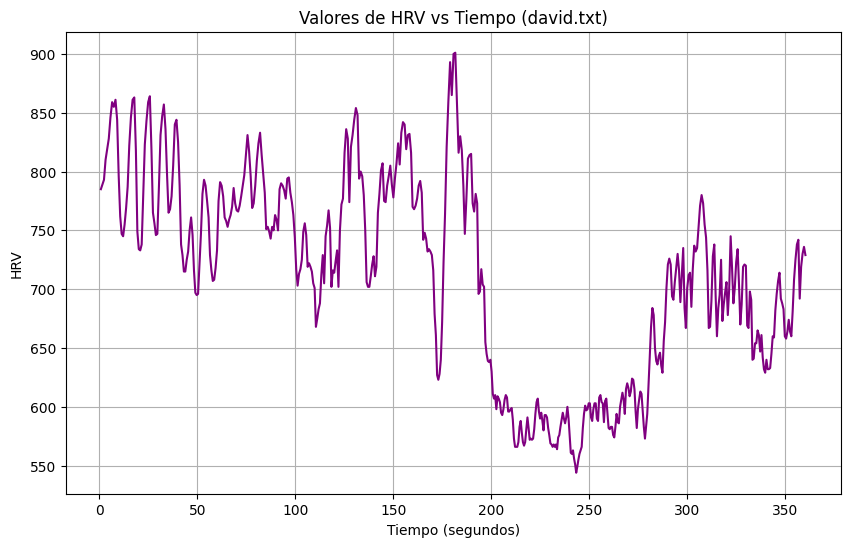

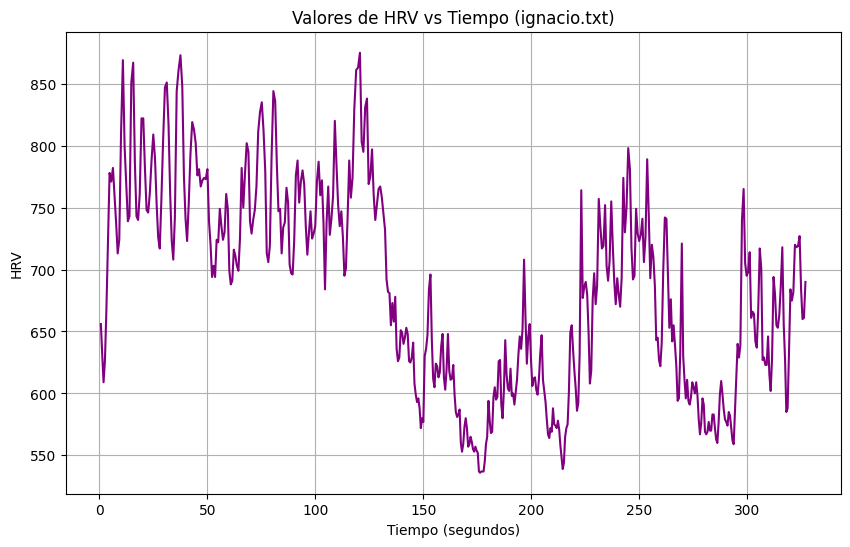

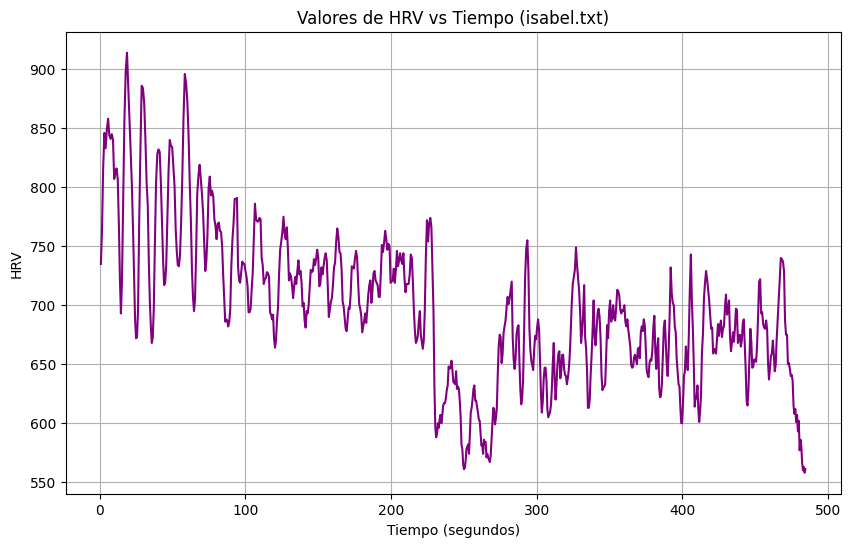

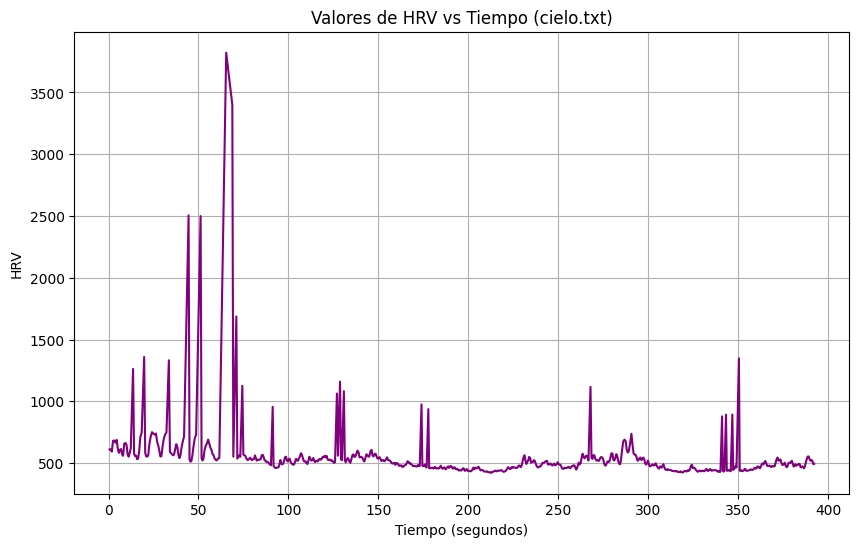

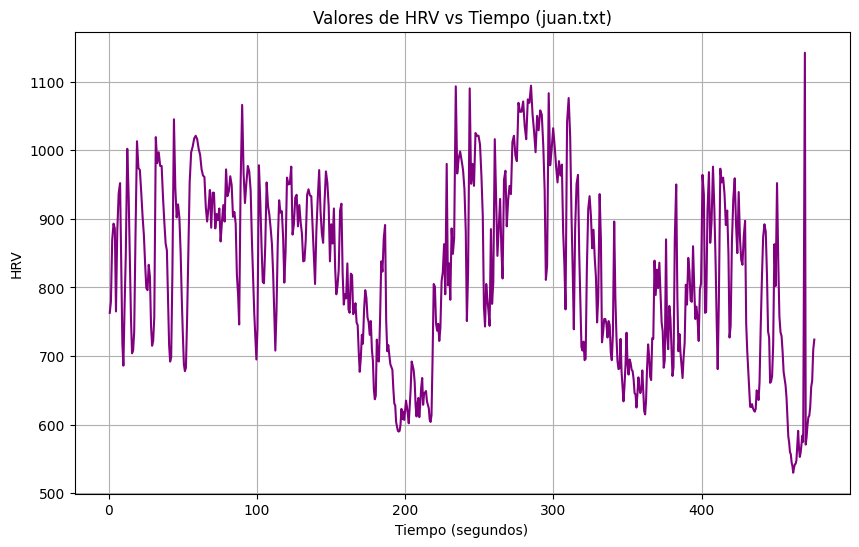

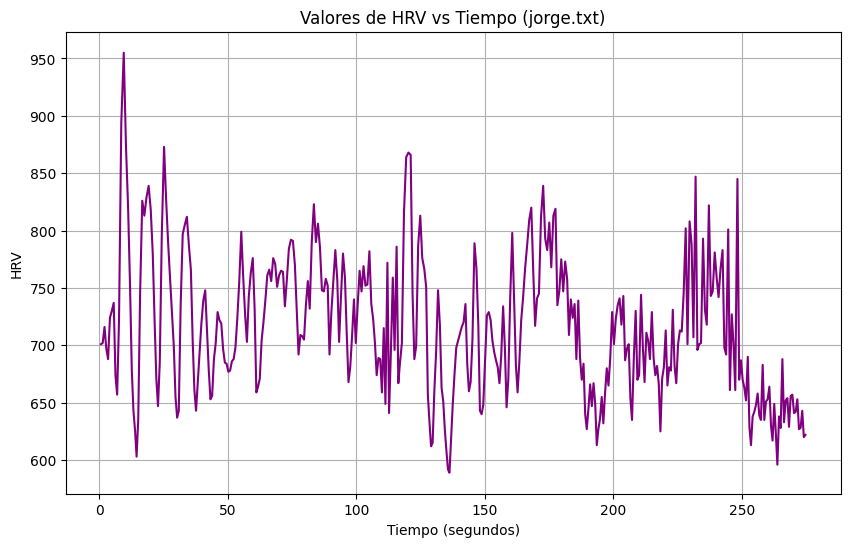

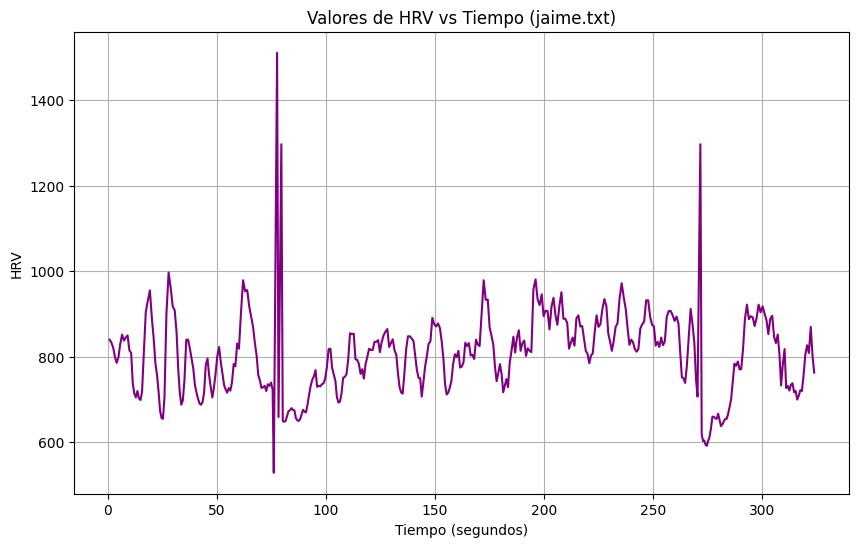

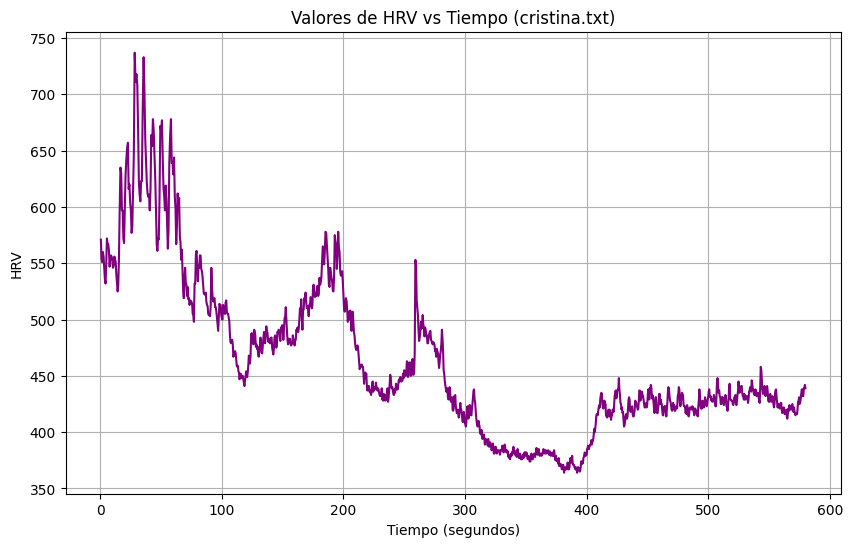

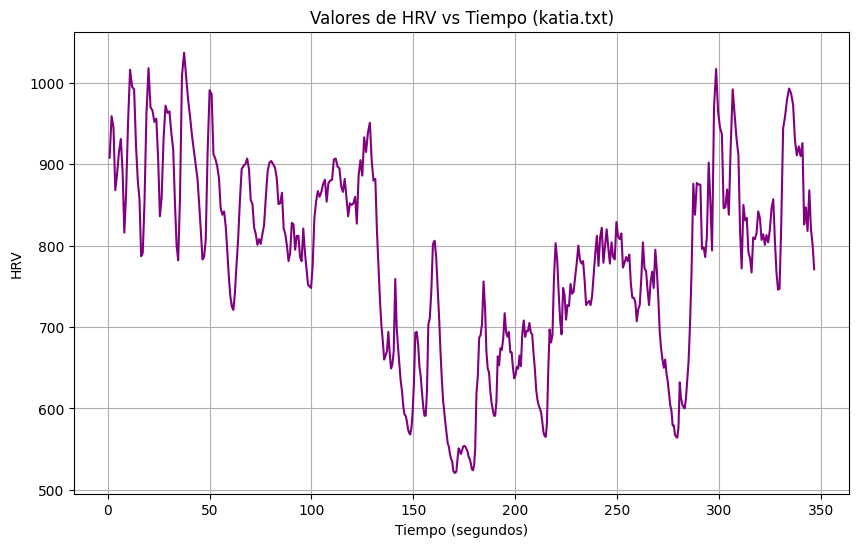

In [13]:
# Ruta a la carpeta de archivos HRV
dir_practice = "/content/drive/MyDrive/CDSI/Notebooks/Practica 4/FISIOLOGICOS"

def cargar_datos_desde_archivo(archivo):
    datos = []
    with open(archivo, 'r') as f:
        for linea in f:
            try:
                datos.append(float(linea.strip()))
            except ValueError:
                print(f"Advertencia: Línea ignorada en {archivo}: {linea.strip()}")
    return datos

def calcular_tiempos_acumulados(datos_hrv):
    """Calcula tiempos acumulados en segundos a partir de datos HRV en milisegundos."""
    tiempos_acumulados = [0]
    for valor_hrv in datos_hrv:
        tiempo_segundos = valor_hrv / 1000
        tiempos_acumulados.append(tiempos_acumulados[-1] + tiempo_segundos)
    return tiempos_acumulados[1:]

def visualizar_hrv_vs_tiempo(archivo):
    """Genera una gráfica de HRV vs tiempo para un archivo dado."""
    nombre_archivo = os.path.basename(archivo)
    datos_hrv = cargar_datos_desde_archivo(archivo)

    if not datos_hrv:
        print(f"Archivo vacío o no válido: {nombre_archivo}")
        return

    tiempos_acumulados = calcular_tiempos_acumulados(datos_hrv)

    plt.figure(figsize=(10, 6))
    plt.plot(tiempos_acumulados, datos_hrv, color='purple', linestyle='-')
    plt.title(f'Valores de HRV vs Tiempo ({nombre_archivo})')
    plt.xlabel('Tiempo (segundos)')
    plt.ylabel('HRV')
    plt.grid(True)
    plt.show()

# Listar archivos .txt en la carpeta HRV
archivos_txt = [os.path.join(dir_practice, archivo) for archivo in os.listdir(dir_practice) if archivo.lower().endswith('.txt')]

for archivo in archivos_txt:
    visualizar_hrv_vs_tiempo(archivo)

**Observaciones**

* Los datos de Ignacio, David, Mario, Isabel, Cristina y Katia muestran intervalos entre latidos elevados al inicio del juego; sin embargo, estos valores disminuyen conforme avanza la experiencia.

* Cielo y Jaime presentan intervalos superiores a 1400 milisegundos, lo que podría indicar la presencia de valores atípicos.

* La mayoría de los participantes tienen intervalos entre latidos en un rango de 200 a 1200 milisegundos.


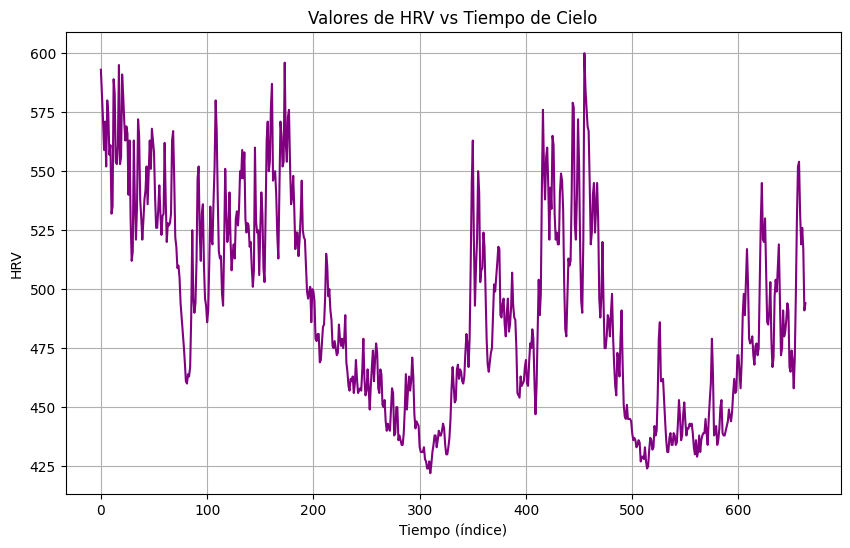

In [7]:
archivo_grafico = "/content/drive/MyDrive/CDSI/Notebooks/Practica 4/FISIOLOGICOS/cielo.txt"
carpeta_hrv = 'HRV'

# Ruta completa del archivo
dir_practice = os.path.join(carpeta_hrv, archivo_grafico)

# Cargar datos de HRV desde el archivo
datos_hrv = cargar_datos_desde_archivo(dir_practice)

# Limitar los datos de HRV al rango de 0 a 1000
datos_hrv_filtrados = [dato for dato in datos_hrv if 0 <= dato <= 600]

plt.figure(figsize=(10, 6))
plt.plot(range(len(datos_hrv_filtrados)), datos_hrv_filtrados, color='purple', linestyle='-')
plt.title(f'Valores de HRV vs Tiempo de Cielo')
plt.xlabel('Tiempo (índice)')
plt.ylabel('HRV')
plt.grid(True)
plt.show()

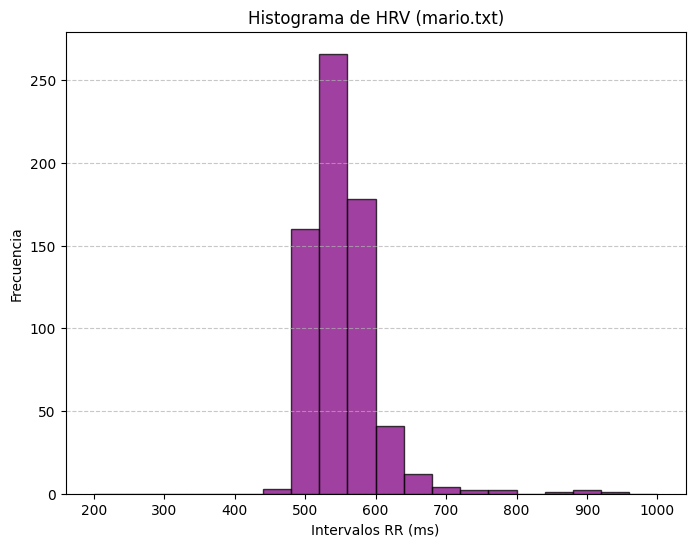

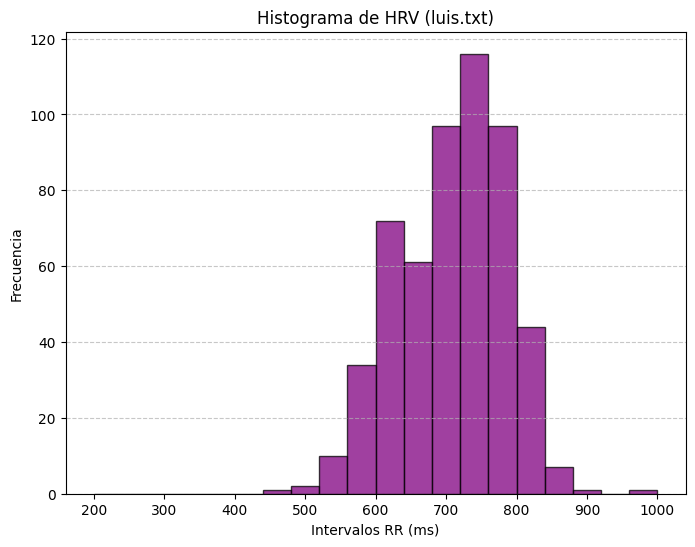

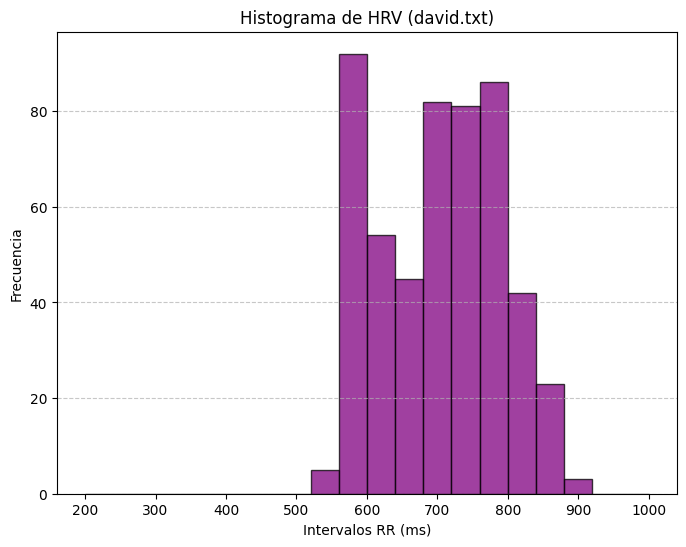

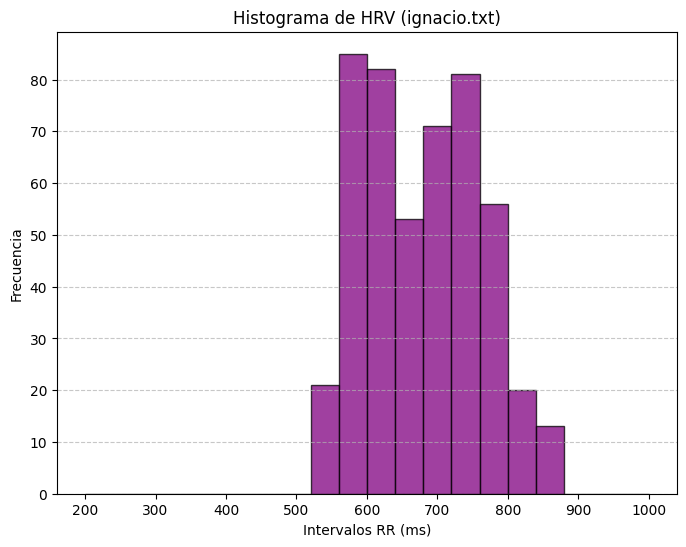

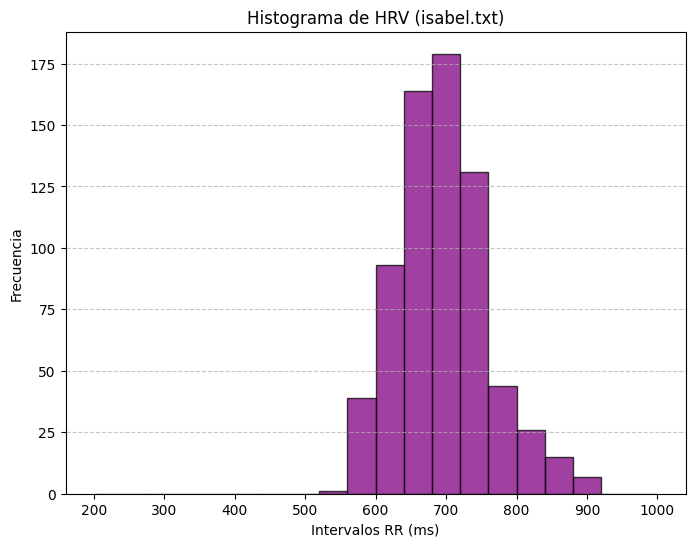

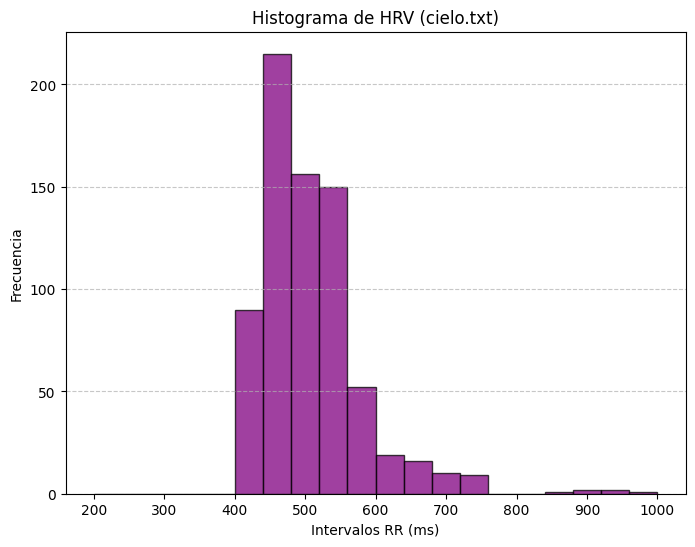

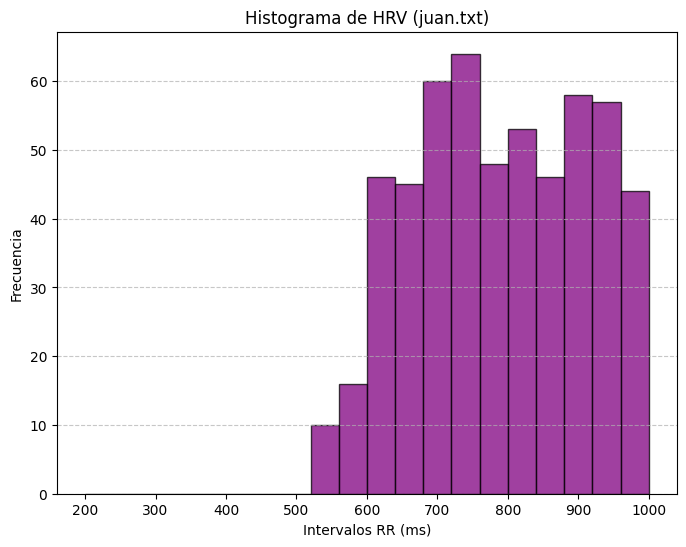

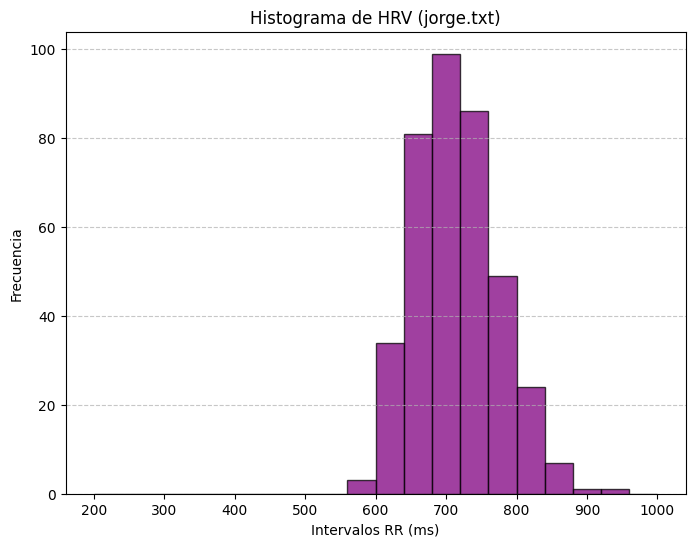

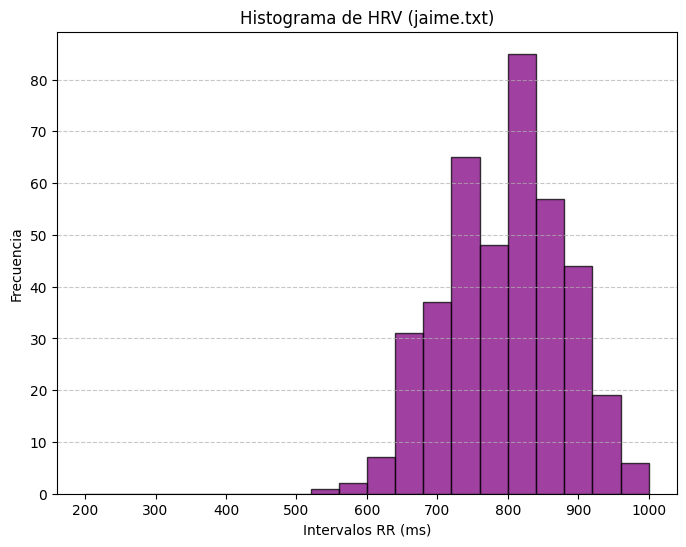

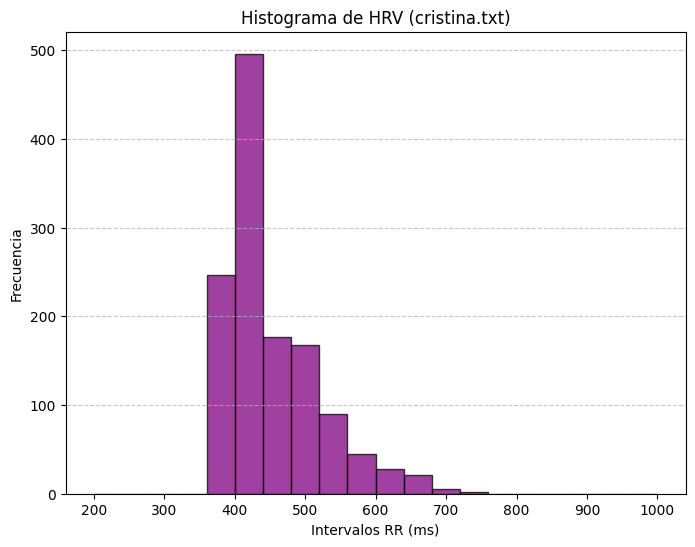

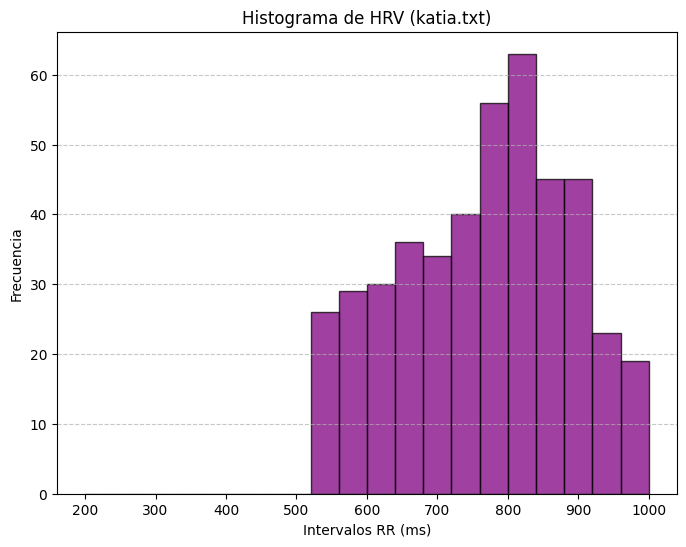

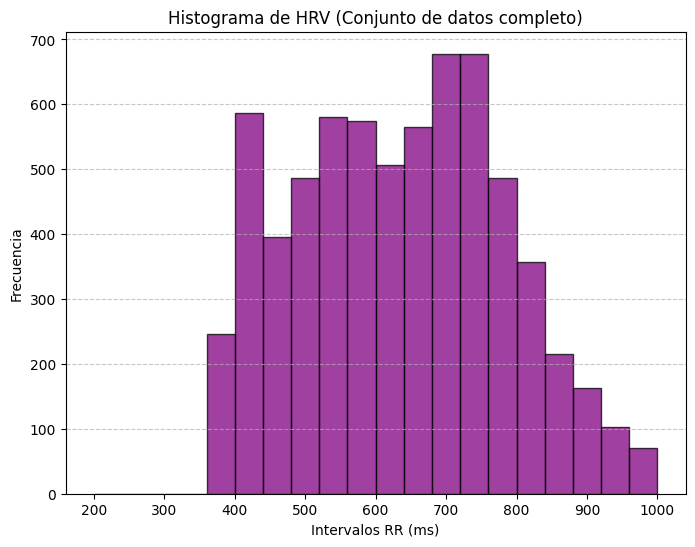

In [14]:
def generar_histograma(datos_hrv, nombre_archivo):
    """Genera un histograma de frecuencia de HRV."""
    if not datos_hrv:
        print(f"Advertencia: No hay datos en {nombre_archivo}")
        return

    plt.figure(figsize=(8, 6))
    plt.hist(datos_hrv, range=(200, 1000), bins=20, color='purple', edgecolor='black', alpha=0.75)
    plt.title(f'Histograma de HRV ({nombre_archivo})')
    plt.xlabel('Intervalos RR (ms)')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Obtener lista de archivos .txt en la carpeta
archivos_txt = [os.path.join(dir_practice, archivo) for archivo in os.listdir(dir_practice) if archivo.lower().endswith('.txt')]

todos_los_datos_hrv = []

for archivo in archivos_txt:
    datos_hrv = cargar_datos_desde_archivo(archivo)

    # Obtención de los datos
    if datos_hrv:
        generar_histograma(datos_hrv, os.path.basename(archivo))
        todos_los_datos_hrv.extend(datos_hrv)

# Generación de histogramas
generar_histograma(todos_los_datos_hrv, 'Conjunto de datos completo')

**Observaciones**

* En el histograma se observa que ocho participantes tienen intervalos entre latidos cercanos a 700 milisegundos o superiores.

* Además, dos participantes presentan sus valores principalmente entre 400 y 500 milisegundos.

### **Segmentación de Señales**

 Para identificar las situaciones que provocan estas variaciones, se realizó un segmentado y etiquetado de los videos de los participantes. Se definieron las siguientes categorías principales:

* Relax
* VR ON
* Going up in the elevator
* Open elevator doors
* Start to walk:  Empezar a caminar en la plancha.
* End to walk: Terminar de caminar sobre la plancha.
* Elevator
* Start red light
* End red light
* Fall
* VR off

El archivo CSV adjunto presenta el segmentado y etiquetado de cada segmento. Este análisis permitirá explorar la relación entre las actividades específicas y los cambios en la HRV.

In [17]:
etiquetado = pd.read_csv("/content/drive/MyDrive/CDSI/Notebooks/Practica 4/FISIOLOGICOS/Heart_Rate_VR_Data.csv")
display(etiquetado.head())

,user,sex,VR experience,heart/vertigo issue,time,event,fear level,hear rate file
0,ignacio,1,1,0,0:00,relax,0,ignacio.txt
1,ignacio,1,1,0,0:56,VR on,0,ignacio.txt
2,ignacio,1,1,0,1:46,going up in the elevator,0,ignacio.txt
3,ignacio,1,1,0,2:03,open elevator doors,0,ignacio.txt
4,ignacio,1,1,0,2:31,start walk,3,ignacio.txt


In [27]:
def tiempo_a_segundos(tiempo_str):
    """Convierte una cadena de tiempo en formato HH:MM:SS o MM:SS a segundos."""
    partes = tiempo_str.split(':')
    if len(partes) == 3:  # Formato HH:MM:SS
        h, m, s = map(int, partes)
        return h * 3600 + m * 60 + s
    elif len(partes) == 2:  # Formato MM:SS
        m, s = map(int, partes)
        return m * 60 + s
    else:
        raise ValueError(f"Formato de tiempo inválido: {tiempo_str}")

def cargar_contextos_desde_csv(archivo_etiquetado):
    """Carga el CSV de etiquetas y convierte la columna de tiempo a segundos, además agrega la columna 'fear level'."""
    etiquetado = pd.read_csv(archivo_etiquetado)
    # Convertir la columna 'time' a segundos
    etiquetado['time_segundos'] = etiquetado['time'].apply(tiempo_a_segundos)
    print("Datos del archivo etiquetado:")
    print(etiquetado.head())
    return etiquetado

def cargar_contexto(etiquetado, tiempo_acumulado, archivo_txt):
    """Obtiene el contexto y el nivel de miedo correspondiente al tiempo dado desde el archivo etiquetado."""
    # Buscar el evento y el nivel de miedo basado en el tiempo acumulado
    instancia = etiquetado[(etiquetado['hear rate file'] == archivo_txt) &
                           (etiquetado['time_segundos'] <= tiempo_acumulado)]

    if not instancia.empty:
        contexto = instancia['event'].values[-1]  # Obtener el último contexto antes del tiempo acumulado
        fear_level = instancia['fear level'].values[-1]  # Obtener el nivel de miedo
    else:
        contexto = None
        fear_level = None
    return contexto, fear_level

def cargar_datos_desde_carpeta(carpeta_hrv, archivo_etiquetado):
    """Carga los datos de HRV, los etiqueta con el contexto y agrega el fear level correspondiente."""
    archivos_txt = [archivo for archivo in os.listdir(carpeta_hrv) if archivo.lower().endswith('.txt')]
    datos_completos = []
    etiquetado = cargar_contextos_desde_csv(archivo_etiquetado)

    for archivo_txt in archivos_txt:
        datos_hrv = cargar_datos_desde_archivo(os.path.join(carpeta_hrv, archivo_txt))
        tiempos_acumulados = calcular_tiempos_acumulados(datos_hrv)

        contextos = []
        fear_levels = []
        for tiempo_acumulado in tiempos_acumulados:
            contexto, fear_level = cargar_contexto(etiquetado, tiempo_acumulado, archivo_txt)
            contextos.append(contexto)
            fear_levels.append(fear_level)

        datos_archivo = pd.DataFrame({
            'filename': archivo_txt,
            'HRV': datos_hrv,
            'Tiempo_Acumulado': tiempos_acumulados,
            'Contexto': contextos,
            'Fear_Level': fear_levels
        })

        datos_archivo = datos_archivo.dropna()
        datos_completos.append(datos_archivo)

    return pd.concat(datos_completos, ignore_index=True)

# Rutas
carpeta_hrv = '/content/drive/MyDrive/CDSI/Notebooks/Practica 4/FISIOLOGICOS'
archivo_etiquetado = '/content/drive/MyDrive/CDSI/Notebooks/Practica 4/FISIOLOGICOS/Heart_Rate_VR_Data.csv'

# Ejecutar procesamiento
datos_completos = cargar_datos_desde_carpeta(carpeta_hrv, archivo_etiquetado)

# Mostrar resultados
print(datos_completos.head())


Datos del archivo etiquetado:
      user  sex  VR experience  heart/vertigo issue  time  \
0  ignacio    1              1                    0  0:00   
1  ignacio    1              1                    0  0:56   
2  ignacio    1              1                    0  1:46   
3  ignacio    1              1                    0  2:03   
4  ignacio    1              1                    0  2:31   

                      event  fear level hear rate file  time_segundos  
0                     relax           0    ignacio.txt              0  
1                     VR on           0    ignacio.txt             56  
2  going up in the elevator           0    ignacio.txt            106  
3       open elevator doors           0    ignacio.txt            123  
4                start walk           3    ignacio.txt            151  
    filename    HRV  Tiempo_Acumulado  Contexto  Fear_Level
0  mario.txt  582.0             0.582  end walk           1
1  mario.txt  574.0             1.156  end walk    

In [28]:
display(datos_completos.head())

,filename,HRV,Tiempo_Acumulado,Contexto,Fear_Level
0,mario.txt,582.0,0.582,end walk,1
1,mario.txt,574.0,1.156,end walk,1
2,mario.txt,568.0,1.724,end walk,1
3,mario.txt,562.0,2.286,end walk,1
4,mario.txt,550.0,2.836,end walk,1


In [38]:
datos_completos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6756 entries, 0 to 6755
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          6756 non-null   object 
 1   HRV               6756 non-null   float64
 2   Tiempo_Acumulado  6756 non-null   float64
 3   Contexto          6756 non-null   object 
 4   Fear_Level        6756 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 264.0+ KB


In [30]:
ruta_guardado = "/content/drive/MyDrive/CDSI/Notebooks/Practica 4/datos_completos.csv"
datos_completos.to_csv(ruta_guardado, index=False)

In [37]:
datos_completos.groupby("Contexto")["HRV"].mean().sort_values(ascending=False)

,HRV
Contexto,
relax,752.478166
VR on,730.776623
VR off,728.625000
open elevator doors,667.456140
elevator,655.908289
fall,654.818182
going up in the elevator,640.548009
start walk,573.469925
start red light,567.516058


Lo realizado anteriormente fue el procesamiento de los datos de frecuencia cardíaca (HRV) y los etiqueta con información contextual del videojuego. Primero, carga las etiquetas del archivo CSV, convirtiendo los tiempos de los eventos del entorno virtual a segundos para facilitar su comparación. A partir de esto, extrae la información del evento y el nivel de miedo (fear level) asociados a cada instante de tiempo. Luego, procesa los archivos de HRV leyendo los datos desde archivos .txt, calculando los tiempos acumulados en los registros de HRV y, para cada instante de tiempo, busca el evento y el nivel de miedo correspondientes en el archivo de etiquetas. Finalmente, asigna la información contextual a cada registro de HRV, asociándolo con el evento del videojuego y el nivel de miedo del participante en ese momento. Se filtran los datos para eliminar valores nulos y se generan los datos completos en un único DataFrame. Con este proceso, se logra integrar la variabilidad de la frecuencia cardíaca con los eventos del videojuego y la respuesta emocional del participante.

En la siguiente figura se puede observar los cambios de la frecuencia cardíaca del estudiante en el transcurso del juego.

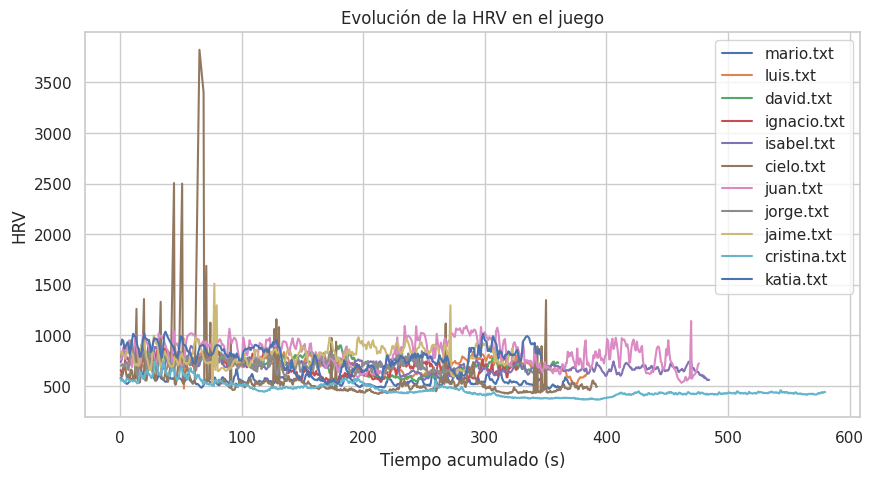

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for filename in datos_completos["filename"].unique():
    subset = datos_completos[datos_completos["filename"] == filename]
    plt.plot(subset["Tiempo_Acumulado"], subset["HRV"], label=filename)

plt.xlabel("Tiempo acumulado (s)")
plt.ylabel("HRV")
plt.title("Evolución de la HRV en el juego")
plt.legend()
plt.show()


In [ ]:
# Resumen estadístico del HRV
print(datos_completos["HRV"].describe())

# Encontrar valores extremos (HRV > 3000)
outliers = datos_completos[datos_completos["HRV"] > 3000]
print(outliers)

count    6756.000000
mean      639.473061
std       163.710818
min       364.000000
25%       518.000000
50%       640.000000
75%       744.000000
max      3822.000000
Name: HRV, dtype: float64
       filename     HRV  Tiempo_Acumulado Contexto  Fear_Level  heart rate
3000  cielo.txt  3822.0            65.407    VR on           0   15.698587
3001  cielo.txt  3400.0            68.807    VR on           0   17.647059


In [32]:
# Definir umbrales fijos
umbral_inferior = 20    # Valor mínimo razonable
umbral_superior = 1500  # Limitar HRV a 1500 ms

# Filtrar el DataFrame eliminando valores fuera de rango
datos_limpiados = datos_completos[(datos_completos["HRV"] >= umbral_inferior) &
                                  (datos_completos["HRV"] <= umbral_superior)]

print(f"Registros antes de limpieza: {len(datos_completos)}")
print(f"Registros después de limpieza: {len(datos_limpiados)}")

Registros antes de limpieza: 6756
Registros después de limpieza: 6750


Se realiza una limpieza debido a la variabilidad de los datos.

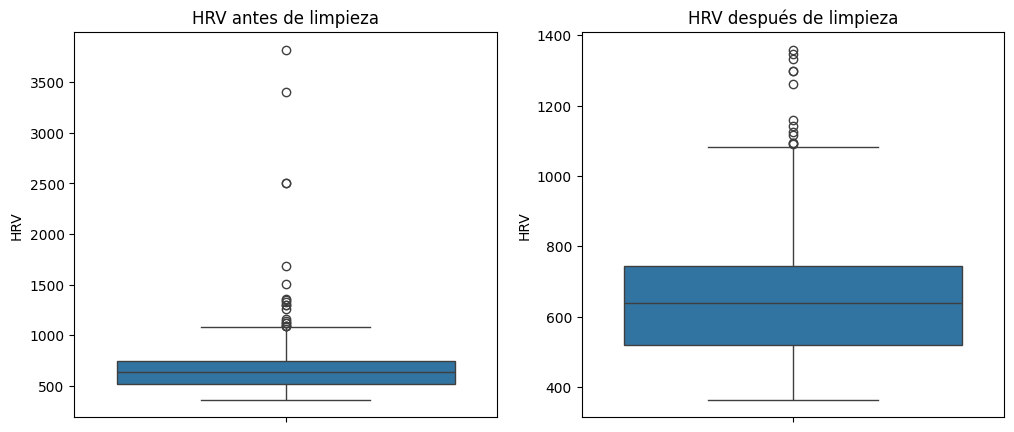

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=datos_completos["HRV"])
plt.title("HRV antes de limpieza")

plt.subplot(1,2,2)
sns.boxplot(y=datos_limpiados["HRV"])
plt.title("HRV después de limpieza")

plt.show()

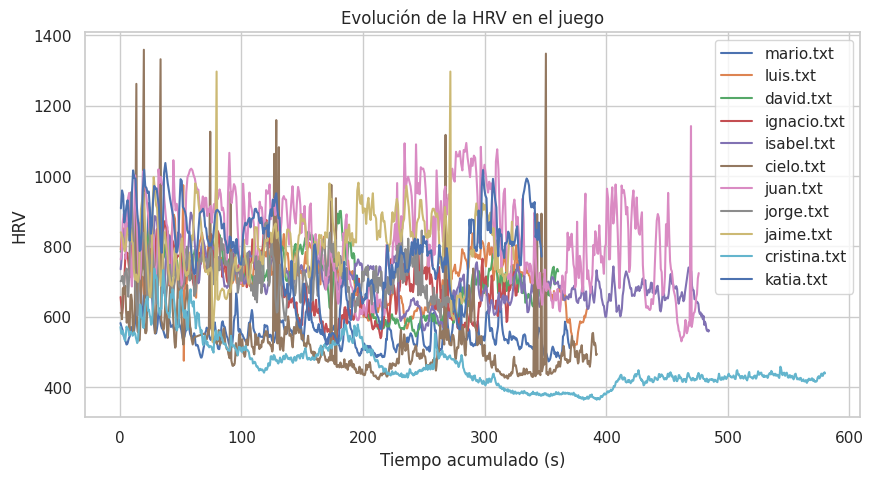

In [ ]:
plt.figure(figsize=(10,5))
for filename in datos_limpiados["filename"].unique():
    subset = datos_limpiados[datos_limpiados["filename"] == filename]
    plt.plot(subset["Tiempo_Acumulado"], subset["HRV"], label=filename)

plt.xlabel("Tiempo acumulado (s)")
plt.ylabel("HRV")
plt.title("Evolución de la HRV en el juego")
plt.legend()
plt.show()

In [39]:
datos_limpiados['heart rate'] = 60000 / datos_limpiados['HRV']

# Now you can group by 'Contexto' (assuming it represents events) and calculate statistics
event_heart_rate_stats = datos_limpiados.groupby('event')['heart rate'].agg(['mean', 'max', 'min'])

print(event_heart_rate_stats)

                                mean         max         min
event                                                       
VR off                     83.144172   96.774194   73.170732
VR on                      85.453305  130.434783   53.285968
elevator                   97.990357  164.835165   53.715309
eleveator                 129.172280  142.180095  106.571936
end red light             138.945883  145.631068   80.645161
end walk                  106.941696  163.487738   65.005417
fall                       94.657307  134.228188   46.260601
going up in the elevator   99.196723  136.054422   51.768766
open elevator doors        93.545800  137.614679   61.919505
relax                      82.478030  126.315789   44.150110
start red light           112.164156  144.927536   44.510386
start walk                110.355222  164.835165   61.162080


<ipython-input-40-f882629f7ec3>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='event', y='heart rate', data=datos_limpiados, palette="Purples")


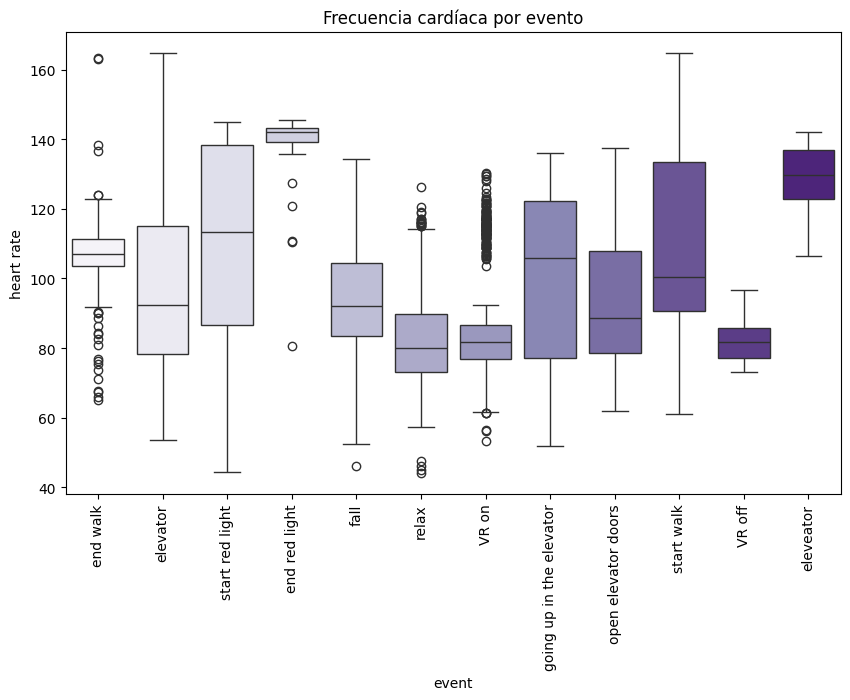

In [40]:
datos_limpiados = datos_limpiados.rename(columns={'Contexto': 'event'})

# Crear un boxplot para visualizar la distribución de la frecuencia cardíaca por evento
plt.figure(figsize=(10, 6))

sns.boxplot(x='event', y='heart rate', data=datos_limpiados, palette="Purples")
plt.title('Frecuencia cardíaca por evento')
plt.xticks(rotation=90)
plt.show()

En términos generales, algunos eventos muestran una mayor variabilidad en la frecuencia cardíaca, lo que sugiere que pueden generar más cambios en la respuesta del cuerpo. Por ejemplo, "start red light" (inicio del semáforo en rojo) y "going up in the ascensor" (subiendo en el ascensor) presentan una amplia distribución de valores, lo que podría indicar una respuesta de estrés o anticipación.

Otros eventos tienen una distribución más estable, indicando una menor alteración. Por ejemplo, "VR off" (apagado de la realidad virtual) y "relax" (relajación) muestran frecuencias cardíacas más consistentes, reflejando un estado de menor excitación.

Además, se observa que en ciertos eventos la frecuencia cardíaca tiende a ser más alta, como en "fail" (fallo o error) y "open ascensor beds" (apertura de puertas del ascensor) , lo que podría estar relacionado con la ansiedad o la expectativa de lo que sigue. Por otro lado, en eventos como "relax" (relajación) , la frecuencia cardíaca es más baja, reflejando un estado de calma.

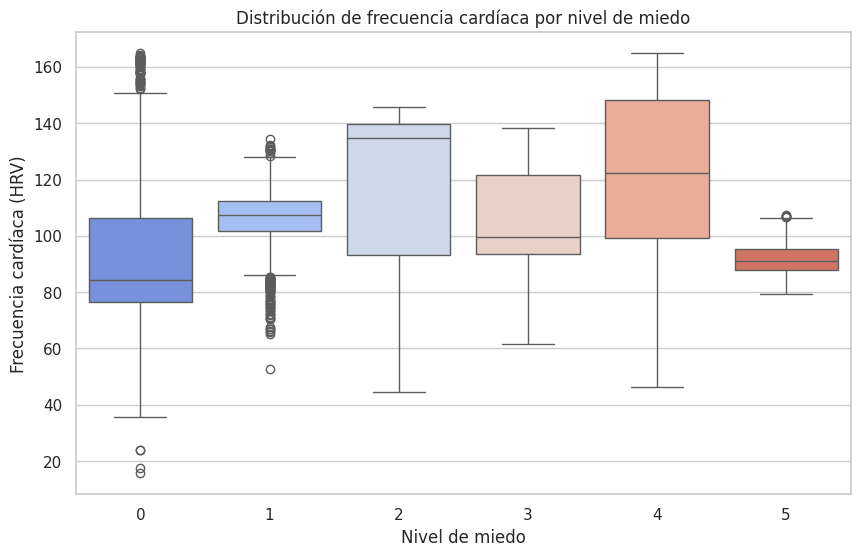

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fear_Level', y='heart rate', data=datos_completos, palette="coolwarm")
plt.title('Distribución de frecuencia cardíaca por nivel de miedo')
plt.xlabel('Nivel de miedo')
plt.ylabel('Frecuencia cardíaca (HRV)')
plt.show()


El gráfico muestra la relación entre la frecuencia cardíaca (HRV) y el nivel de miedo percibido.

En términos generales, algunos niveles de miedo presentan una mayor variabilidad en la frecuencia cardíaca, lo que sugiere que pueden generar respuestas más diversas en las personas. Por ejemplo, en los niveles 2 y 4 , se observa una amplia dispersión de los valores, lo que indica que algunas personas pueden experimentar un fuerte aumento en la frecuencia cardíaca mientras que otras muestran respuestas más moderadas.

Otros niveles de miedo tienen una distribución más estable, indicando una menor variabilidad en la respuesta fisiológica. Por ejemplo, el nivel 5 muestra valores más agrupados, sugiriendo que las personas que reportaron este nivel de miedo tuvieron una reacción más uniforme en términos de frecuencia cardíaca.

In [ ]:
datos_limpiados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6750 entries, 0 to 6755
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          6750 non-null   object 
 1   HRV               6750 non-null   float64
 2   Tiempo_Acumulado  6750 non-null   float64
 3   Contexto          6750 non-null   object 
 4   Fear_Level        6750 non-null   int64  
 5   heart rate        6750 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 369.1+ KB


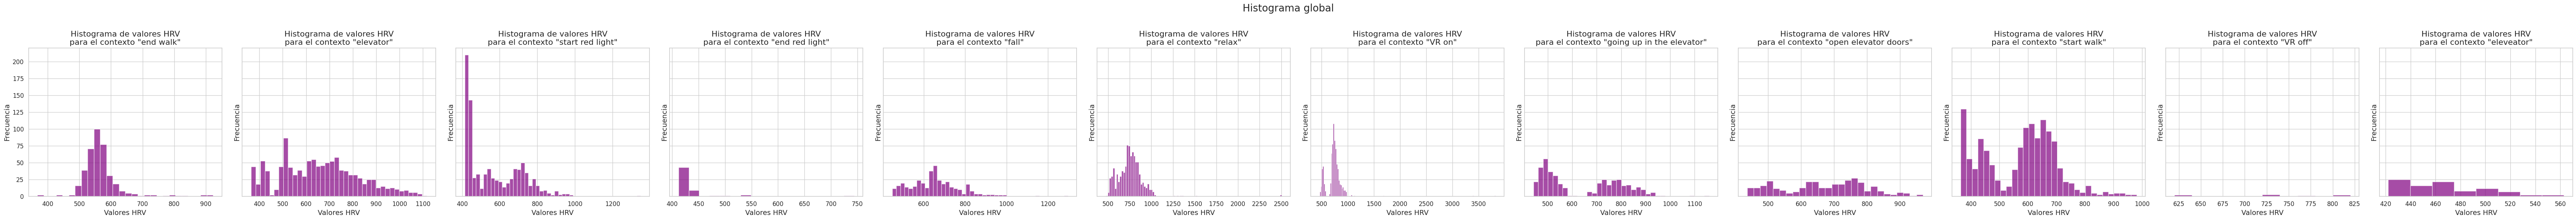

In [ ]:
# Obtener todos los contextos únicos
contextos_unicos = datos_limpiados['Contexto'].unique()

# Calcular el número total de subplots necesarios
num_subplots = len(contextos_unicos)

fig, axs = plt.subplots(1, num_subplots, figsize=(6 * num_subplots, 6), sharey=True)
plt.suptitle(f'Histograma global', fontsize=20, y=1.02)

bin_width = 20

for i, contexto in enumerate(contextos_unicos):
    datos_contexto = datos_completos[datos_completos['Contexto'] == contexto]

    # Calcular el número de bins necesario para cubrir todo el rango de datos
    min_value = datos_contexto['HRV'].min()
    max_value = datos_contexto['HRV'].max()
    num_bins = int(np.ceil((max_value - min_value) / bin_width))

    axs[i].hist(datos_contexto['HRV'], bins=num_bins, alpha=0.7, color='purple')
    axs[i].set_title(f'Histograma de valores HRV\npara el contexto "{contexto}"', fontsize=16)
    axs[i].set_xlabel('Valores HRV', fontsize=14)
    axs[i].set_ylabel('Frecuencia', fontsize=14)
    axs[i].tick_params(axis='both', which='major', labelsize=12)
    axs[i].grid(True)

plt.tight_layout()
plt.show()

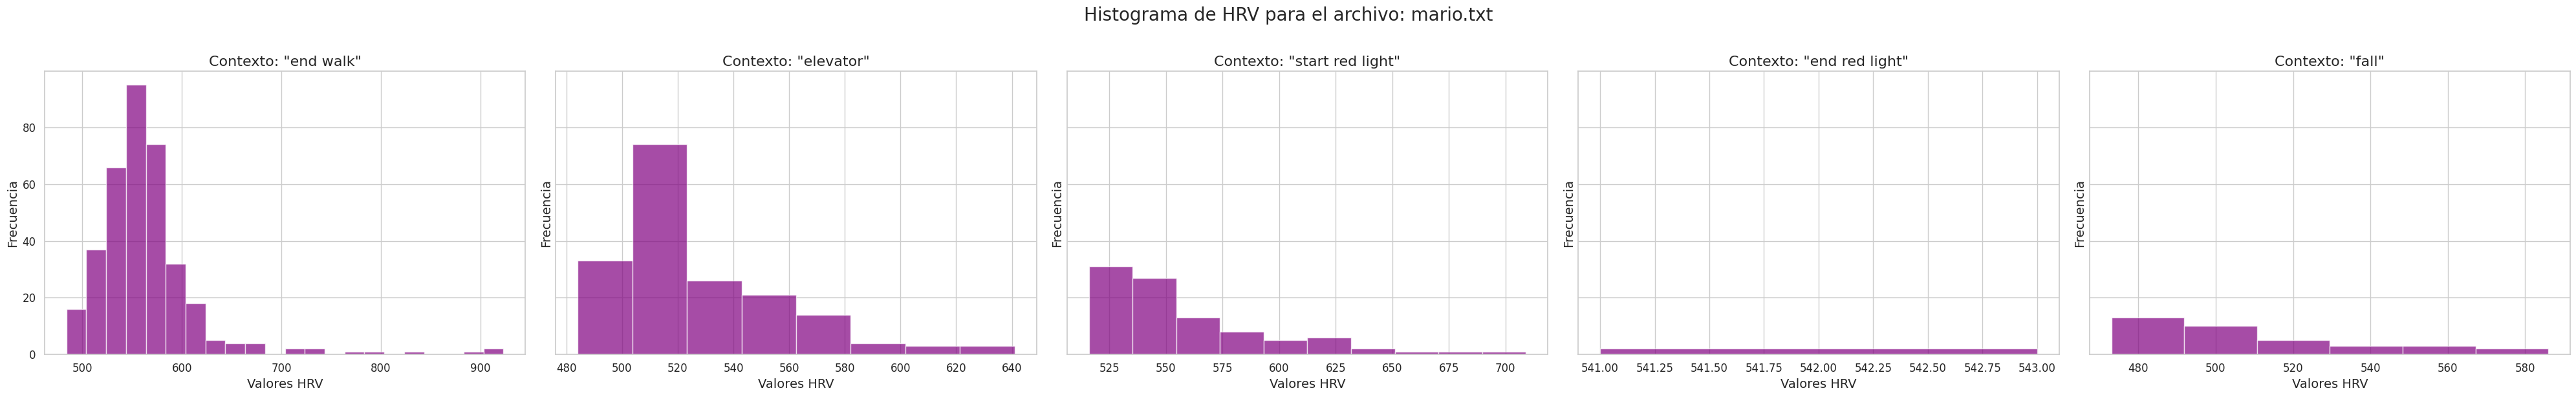

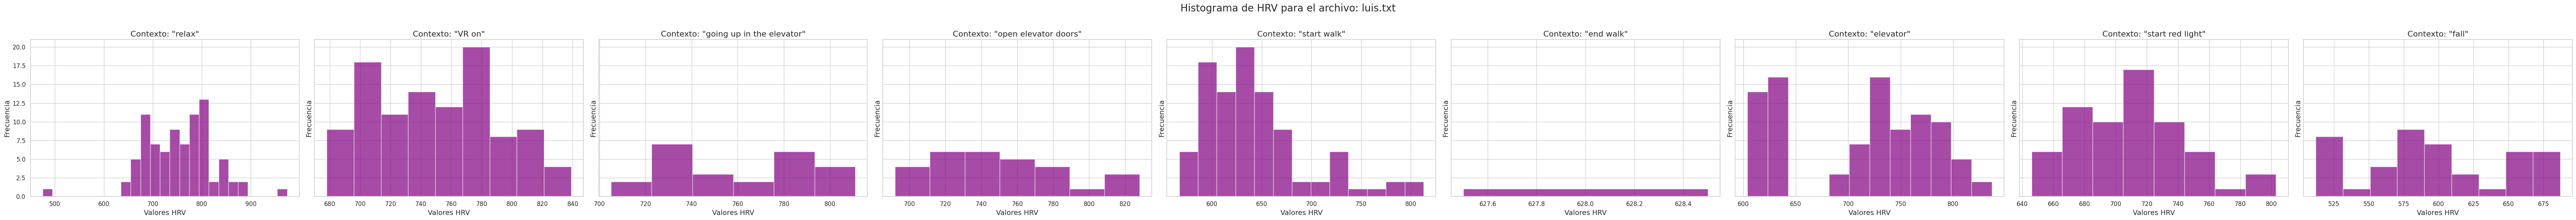

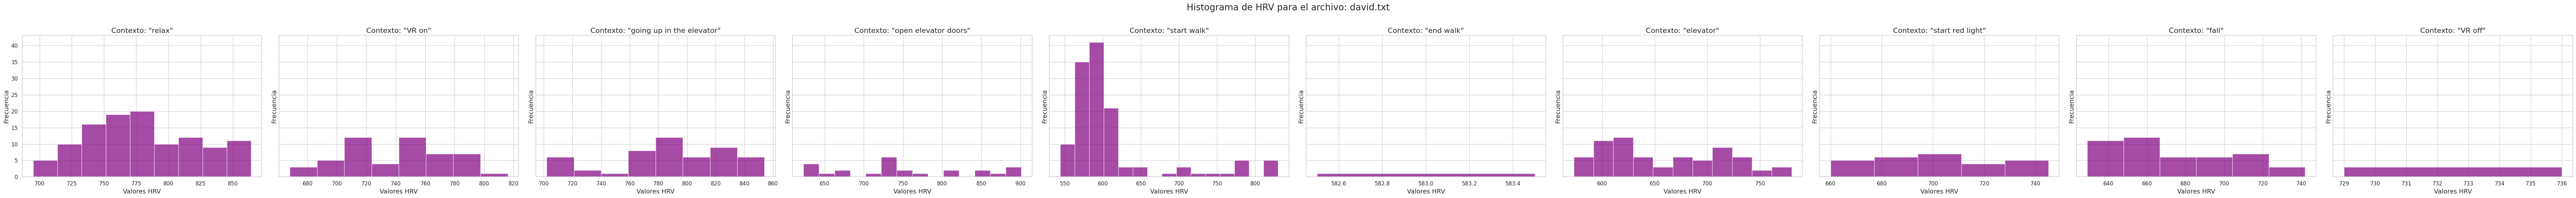

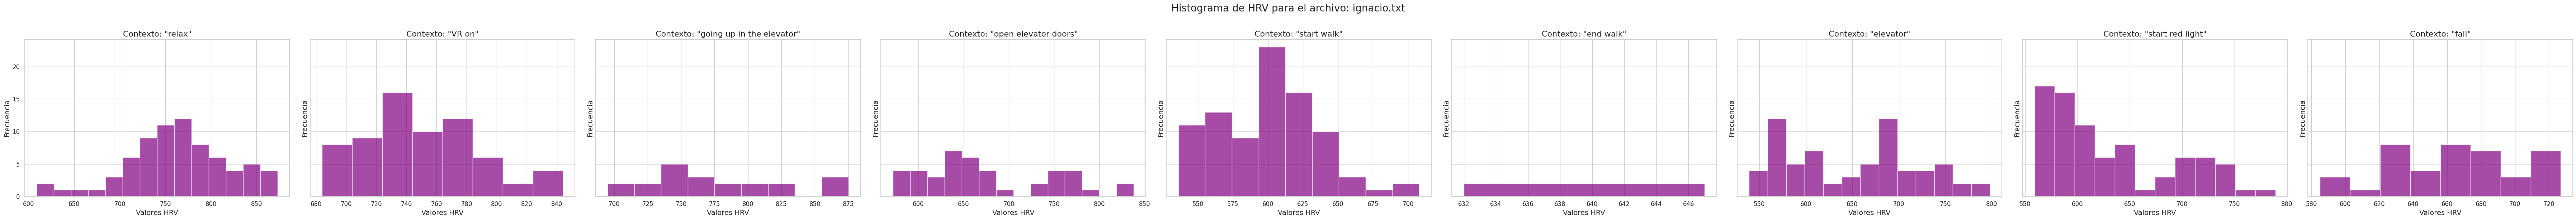

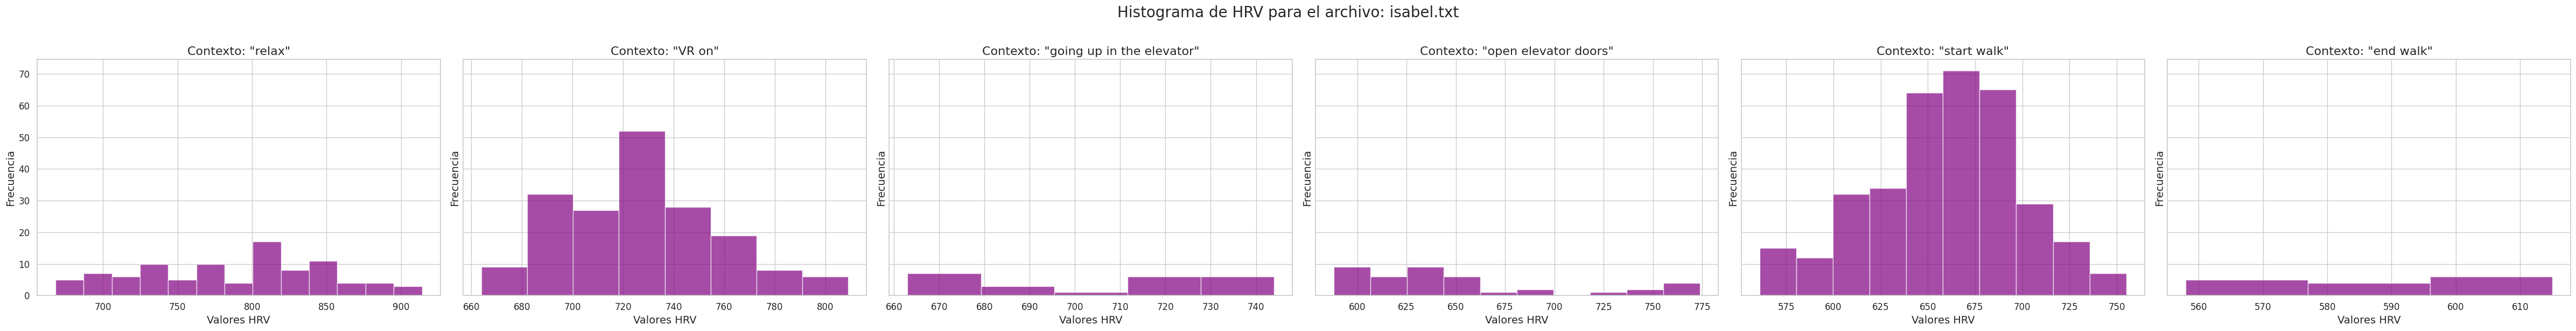

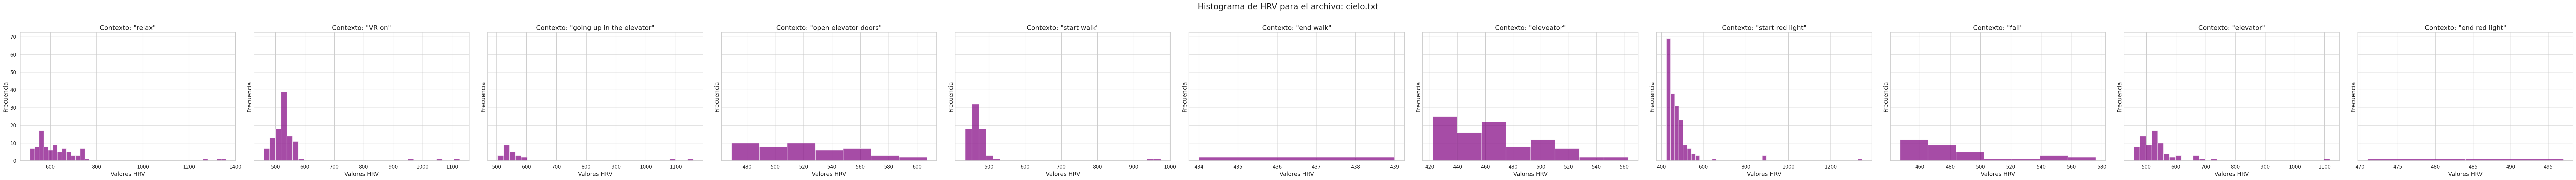

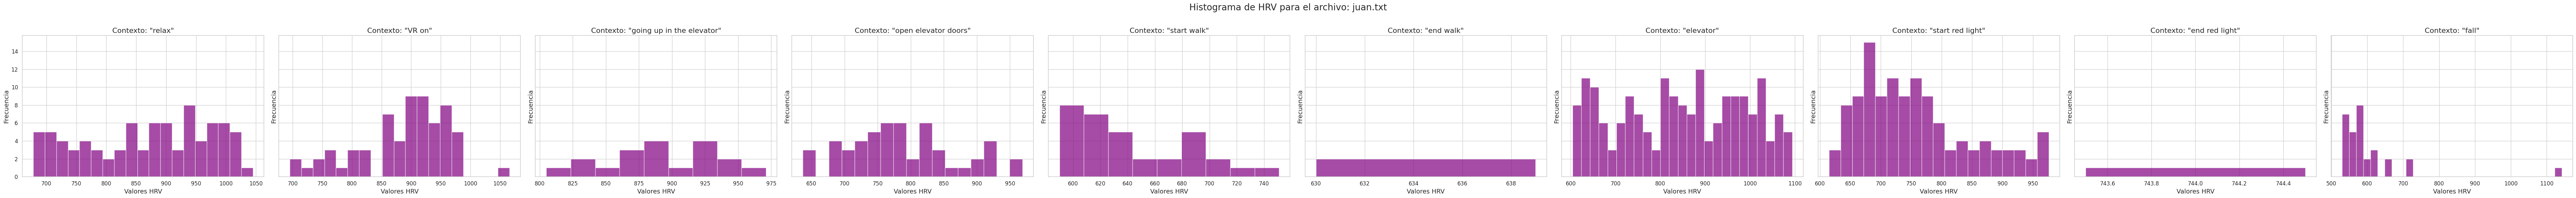

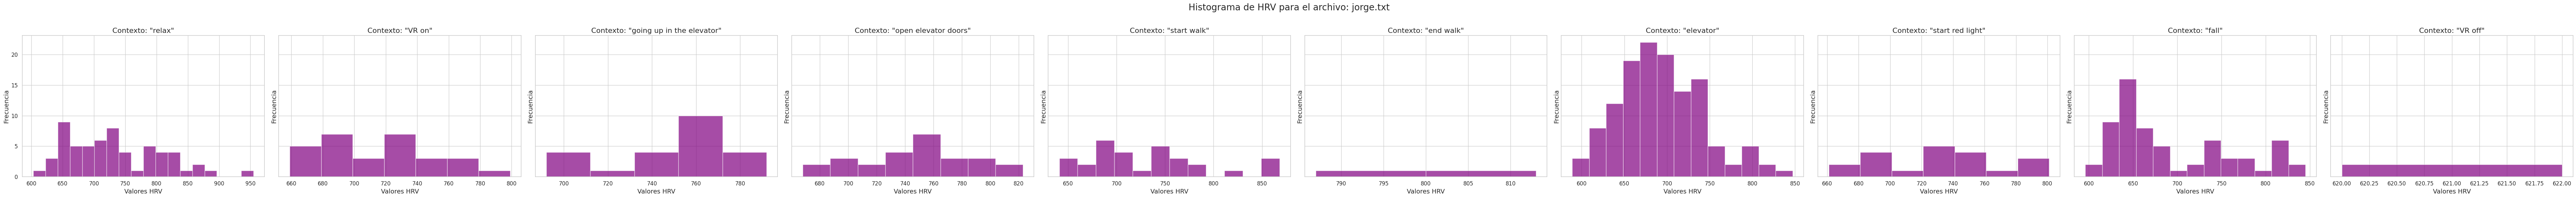

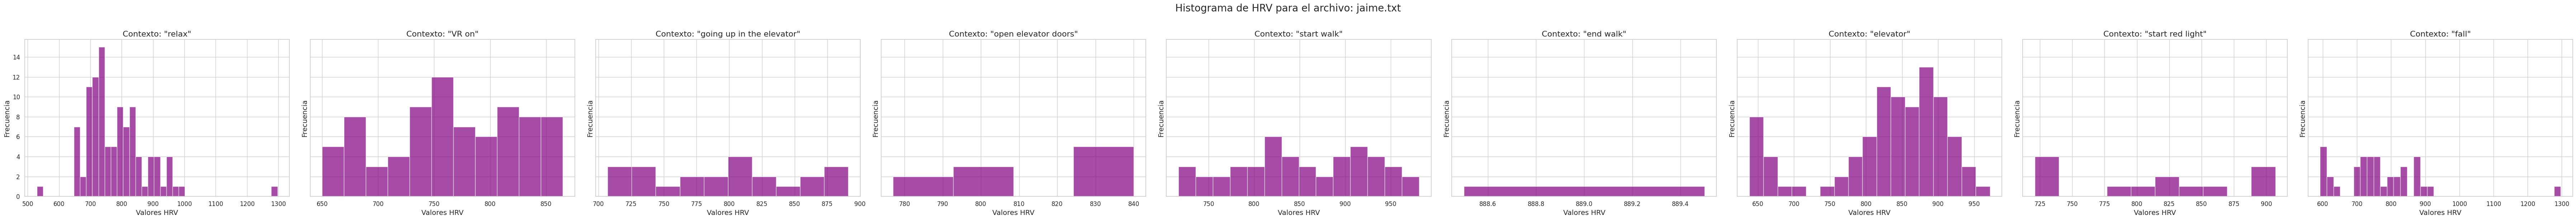

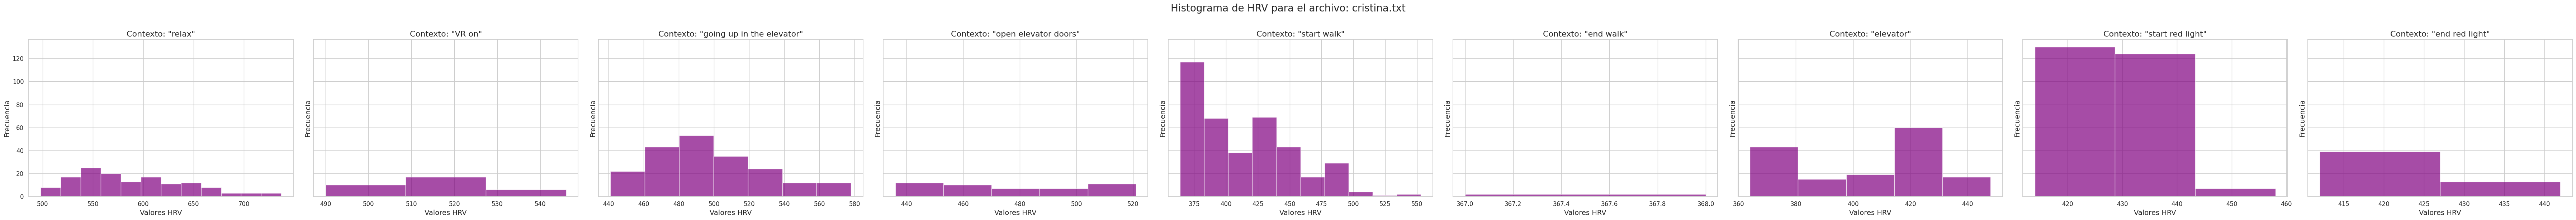

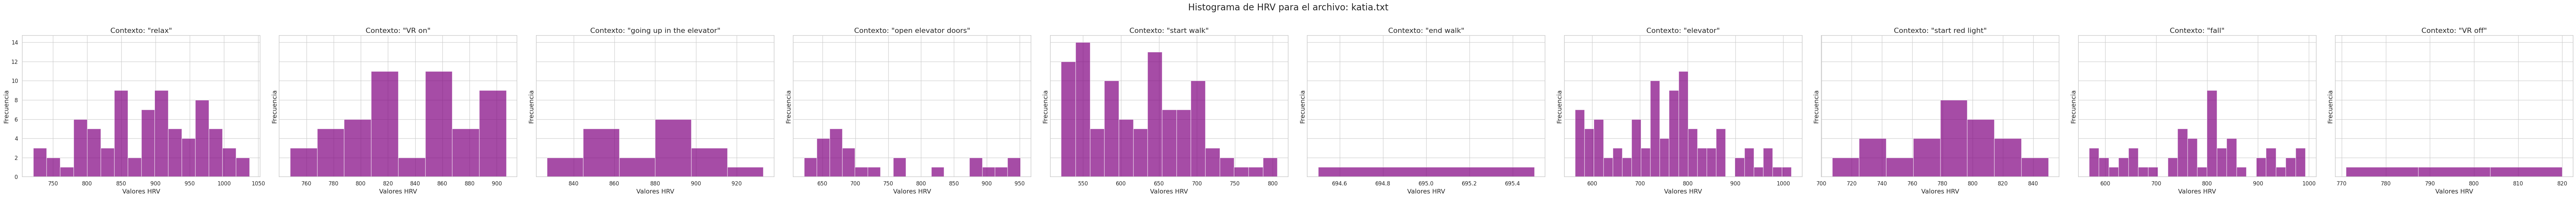

In [ ]:
# Obtener todos los archivos únicos
archivos_unicos = datos_limpiados['filename'].unique()

# Especificar el ancho de los bins
bin_width = 20

# Iterar sobre cada archivo
for archivo in archivos_unicos:
    # Obtener los datos correspondientes a este archivo
    datos_archivo = datos_limpiados[datos_limpiados['filename'] == archivo]

    # Obtener todos los contextos únicos para este archivo
    contextos_unicos = datos_archivo['Contexto'].unique()

    num_subplots = len(contextos_unicos)
    fig, axs = plt.subplots(1, num_subplots, figsize=(8 * num_subplots, 6), sharey=True)
    plt.suptitle(f'Histograma de HRV para el archivo: {archivo}', fontsize=20, y=1.02)

    # Iterar sobre cada contexto y crear un histograma para cada uno en un subplot diferente
    for i, contexto in enumerate(contextos_unicos):
        datos_contexto = datos_archivo[datos_archivo['Contexto'] == contexto]

        min_value = datos_contexto['HRV'].min()
        max_value = datos_contexto['HRV'].max()

        if min_value == max_value:
            num_bins = 1
        else:
            num_bins = int(np.ceil((max_value - min_value) / bin_width))

        axs[i].hist(datos_contexto['HRV'], bins=num_bins, alpha=0.7, color='purple')
        axs[i].set_title(f'Contexto: "{contexto}"', fontsize=16)
        axs[i].set_xlabel('Valores HRV', fontsize=14)
        axs[i].set_ylabel('Frecuencia', fontsize=14)
        axs[i].tick_params(axis='both', which='major', labelsize=12)
        axs[i].grid(True)

    plt.tight_layout()
    plt.show()

### **Extracción de características**

Las series temporales de la HRV se extraerán a partir de los intervalos RR (tiempo entre latidos cardíacos) medidos en milisegundos. A partir de estos datos, se calcularán las siguientes características de la variabilidad de la frecuencia cardíaca (HRV):

* SDNN (Desviación Estándar de los Intervalos RR) :
Mide la variabilidad total de los intervalos RR. Un valor más alto indica una mayor variabilidad en los ritmos cardíacos.

* RMSSD (Raíz Cuadrada de las Diferencias Cuadráticas Sucesivas) :
Refleja la variabilidad a corto plazo y una respuesta rápida del sistema nervioso autónomo.

* NN50 y pNN50 :
    * NN50 representa el número de diferencias sucesivas entre intervalos RR que superan los 50 ms.
    * pNN50 es el porcentaje de NN50 con respecto al total de intervalos RR.
Ambas métricas indican variabilidad a corto plazo.

* SD1 y SD2 (Parámetros del Espacio de Poincaré) :
  * SD1 mide la dispersión de los puntos en dirección perpendicular al eje de
identidad.
  * SD2 mide la dispersión en dirección paralela al eje de identidad.
Estos parámetros brindan información sobre la variabilidad a largo plazo.

* LF (Baja Frecuencia) y HF (Alta Frecuencia) :
    * Representan diferentes componentes de la variabilidad en bandas de frecuencia: LF se asocia con la actividad simpática y, en menor medida, con la parasimpática.
    * HF está principalmente relacionada con la actividad parasimpática.
    
    * Relación LF/HF : Indica el equilibrio entre la actividad del sistema simpático y parasimpático. Un valor elevado sugiere predominio simpático.

* TINN (Interpolación Triangular de los Intervalos NN) :
Se utiliza como medida de la variabilidad a largo plazo.

* Otras características : Se analizarán métricas adicionales que proporcionan información sobre la forma y distribución de los intervalos RR, como moda, entropía de Shannon, clasificación, coeficiente de variación (CV), PEI, mediana NNI, rango NNI, asimetría, curtosis y el área bajo la curva.

* ContextoLongitud : Representa la duración de un segmento de contexto específico, medido en segundos.

In [42]:
# Función principal para calcular las características de HRV
def calcular_caracteristicas_hrv(datos_limpiados):
    caracteristicas = []

    # Inicializar variables para mantener el contexto anterior y la serie temporal actual
    contexto_anterior = None
    serie_temporal_actual = []
    filename = None
    contexto = None
    Fear_Level = None

    for i, row in datos_limpiados.iterrows():
        if row['event'] != contexto_anterior:
            if serie_temporal_actual:
                caracteristicas.extend(calcular_caracteristicas_serie(serie_temporal_actual, filename, contexto, Fear_Level))
                # Reiniciar la serie temporal actual
                serie_temporal_actual = []

        # Agregar el valor HRV actual a la serie temporal actual
        serie_temporal_actual.append(row['HRV'])

        # Actualizar el contexto anterior para la próxima iteración
        contexto_anterior = row['event']
        filename = row['filename']
        contexto = row['event']
        Fear_Level = row['Fear_Level']

    # Calcular características para la última serie temporal si existe
    if serie_temporal_actual:
        caracteristicas.extend(calcular_caracteristicas_serie(serie_temporal_actual, filename, contexto, Fear_Level))

    return pd.DataFrame(caracteristicas)

def calcular_caracteristicas_serie(serie_temporal, filename, contexto, Fear_Level):
    caracteristicas_serie = []
    rr_intervals = np.array(serie_temporal)

    rr_intervals = rr_intervals[~np.isnan(rr_intervals)]  # Eliminar NaN

    if len(rr_intervals) < 2:
        return caracteristicas_serie

    # Calcular métricas de HRV
    sd1, sd2 = np.std(np.diff(rr_intervals)), np.std(np.diff(np.diff(rr_intervals)))
    rr_intervals_norm = rr_intervals / np.sum(rr_intervals)
    rr_intervals_norm = rr_intervals_norm[rr_intervals_norm > 0]

    caracteristicas_serie.append({
        'filename': filename,
        'Contexto': contexto,
        'Fear_Level': Fear_Level,
        'SDNN': np.std(rr_intervals),
        'RMSSD': np.sqrt(np.mean(np.diff(rr_intervals) ** 2)),
        'NN50': np.sum(np.abs(np.diff(rr_intervals)) > 50),
        'pNN50': (np.sum(np.abs(np.diff(rr_intervals)) > 50)) / len(rr_intervals),
        'SD1': sd1,
        'SD2': sd2,
        'LF': np.sum((rr_intervals > 0.04) & (rr_intervals < 0.15)),
        'HF': np.sum(rr_intervals > 0.15),
        'LF/HF Ratio': (np.sum((rr_intervals > 0.04) & (rr_intervals < 0.15))) / (np.sum(rr_intervals > 0.15)),
        'TINN': np.max(np.diff(np.sort(rr_intervals))),
        'Mode': np.argmax(np.bincount(rr_intervals.astype(int))),
        'Shannon Entropy': -np.sum(rr_intervals_norm * np.log(rr_intervals_norm)),
        'Correlation': np.corrcoef(rr_intervals[:-1], rr_intervals[1:])[0, 1] if len(rr_intervals) > 1 else 0,
        'CV': np.std(rr_intervals) / np.mean(rr_intervals) if np.mean(rr_intervals) != 0 else 0,
        'PEI': np.sum(np.abs(np.diff(rr_intervals)) > 20) / len(rr_intervals),
        'Median NNI': np.median(rr_intervals),
        'Range NNI': np.max(rr_intervals) - np.min(rr_intervals),
        'Skewness': np.sum((rr_intervals - np.mean(rr_intervals)) ** 3) / (len(rr_intervals) * np.std(rr_intervals) ** 3),
        'Kurtosis': np.sum((rr_intervals - np.mean(rr_intervals)) ** 4) / (len(rr_intervals) * np.std(rr_intervals) ** 4),
        'Area Under Curve': np.trapz(rr_intervals),
        'LongitudContexto': np.sum(rr_intervals) / 1000
    })

    return caracteristicas_serie


# Aplicar la función al DataFrame
características_hrv = calcular_caracteristicas_hrv(datos_limpiados)
display(características_hrv)

/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,filename,Contexto,Fear_Level,SDNN,RMSSD,NN50,pNN50,SD1,SD2,LF,...,Shannon Entropy,Correlation,CV,PEI,Median NNI,Range NNI,Skewness,Kurtosis,Area Under Curve,LongitudContexto
0,mario.txt,end walk,1,53.733350,24.697672,10,0.027701,24.697012,30.641434,0,...,5.884707,0.894539,0.095283,0.127424,558.0,439.0,3.244484,19.093124,203031.5,203.581
1,mario.txt,elevator,0,34.225840,13.373155,1,0.007874,13.371563,14.045813,0,...,4.842143,0.924196,0.064677,0.118110,520.0,156.0,1.165853,4.023229,66676.0,67.206
2,mario.txt,start red light,1,39.057872,22.017401,3,0.031579,22.017237,24.160025,0,...,4.551514,0.842143,0.069883,0.210526,544.0,193.0,1.556606,5.260293,52561.0,53.096
3,mario.txt,end red light,1,1.000000,2.000000,0,0.000000,0.000000,NaN,0,...,0.693145,NaN,0.001845,0.000000,542.0,2.0,0.000000,1.000000,542.0,1.084
4,mario.txt,elevator,0,20.238201,8.281304,0,0.000000,8.218248,8.387383,0,...,3.931077,0.916334,0.038766,0.000000,519.0,85.0,0.317791,2.498579,26115.5,26.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,katia.txt,fall,4,71.146064,21.949075,0,0.000000,19.752206,28.027264,0,...,3.085555,0.959585,0.104578,0.272727,666.5,227.0,-0.016666,1.620970,14298.5,14.967
105,katia.txt,elevator,0,137.143643,53.178943,12,0.307692,52.393646,74.173872,0,...,3.648356,0.925827,0.171661,0.589744,838.0,453.0,-0.388647,1.823466,30420.0,31.158
106,katia.txt,start red light,1,26.069906,37.221559,1,0.100000,37.208123,65.103643,0,...,2.302063,0.075015,0.032321,0.400000,809.0,83.0,0.007339,1.869012,7253.5,8.066
107,katia.txt,fall,2,70.984675,38.946545,4,0.129032,38.906455,48.997804,0,...,3.430627,0.853559,0.082309,0.451613,842.0,247.0,0.373586,2.009657,25893.5,26.735


In [43]:
# Filtrar las clases con pocos datos
conteo_clases = características_hrv['Contexto'].value_counts()
umbral = 10  # Definir el umbral mínimo de muestras por clase
clases_validas = conteo_clases[conteo_clases >= umbral].index

# Filtrar las filas del DataFrame para mantener solo las clases válidas
características_hrv = características_hrv[características_hrv['Contexto'].isin(clases_validas)]
display(características_hrv)

,filename,Contexto,Fear_Level,SDNN,RMSSD,NN50,pNN50,SD1,SD2,LF,...,Shannon Entropy,Correlation,CV,PEI,Median NNI,Range NNI,Skewness,Kurtosis,Area Under Curve,LongitudContexto
1,mario.txt,elevator,0,34.225840,13.373155,1,0.007874,13.371563,14.045813,0,...,4.842143,0.924196,0.064677,0.118110,520.0,156.0,1.165853,4.023229,66676.0,67.206
2,mario.txt,start red light,1,39.057872,22.017401,3,0.031579,22.017237,24.160025,0,...,4.551514,0.842143,0.069883,0.210526,544.0,193.0,1.556606,5.260293,52561.0,53.096
4,mario.txt,elevator,0,20.238201,8.281304,0,0.000000,8.218248,8.387383,0,...,3.931077,0.916334,0.038766,0.000000,519.0,85.0,0.317791,2.498579,26115.5,26.625
5,mario.txt,fall,1,29.873021,11.513967,0,0.000000,11.482018,13.456871,0,...,3.581831,0.927324,0.058648,0.055556,499.0,113.0,1.025574,2.994650,17841.0,18.337
6,luis.txt,relax,0,70.515300,72.092310,11,0.130952,72.088440,124.246093,0,...,4.426385,0.482435,0.093307,0.488095,761.5,499.0,-0.311893,5.137143,62722.0,63.482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,katia.txt,start red light,2,33.374441,23.112561,0,0.000000,23.062274,34.053047,0,...,3.090104,0.767288,0.043213,0.318182,780.0,122.0,-0.294819,2.028384,16203.0,16.991
104,katia.txt,fall,4,71.146064,21.949075,0,0.000000,19.752206,28.027264,0,...,3.085555,0.959585,0.104578,0.272727,666.5,227.0,-0.016666,1.620970,14298.5,14.967
105,katia.txt,elevator,0,137.143643,53.178943,12,0.307692,52.393646,74.173872,0,...,3.648356,0.925827,0.171661,0.589744,838.0,453.0,-0.388647,1.823466,30420.0,31.158
106,katia.txt,start red light,1,26.069906,37.221559,1,0.100000,37.208123,65.103643,0,...,2.302063,0.075015,0.032321,0.400000,809.0,83.0,0.007339,1.869012,7253.5,8.066


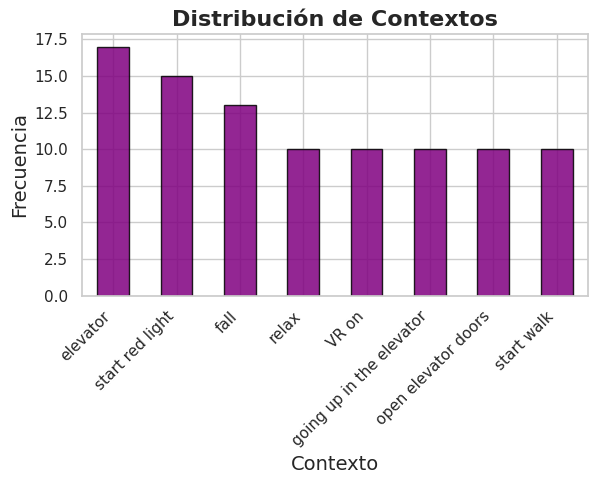

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 5))
características_hrv['Contexto'].value_counts().plot(kind='bar', alpha=0.85, color='purple', edgecolor='black')

plt.title('Distribución de Contextos', fontsize=16, fontweight='bold')
plt.xlabel('Contexto', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)


plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### **Selección de característticas**

In [44]:
características = características_hrv.dropna()
X = características.drop(['Contexto', 'filename'], axis=1)
y = características['Contexto']

In [45]:
# Eliminar valores NaN
características = características_hrv.dropna()

# Separar variables predictoras (X) y variable objetivo (y)
X = características.drop(['Contexto', 'filename'], axis=1)
y = características['Contexto']

# Convertir X a valores numéricos (evitar problemas con mutual_info_classif)
X = X.apply(pd.to_numeric, errors='coerce')

# Calcular la importancia de las características usando mutual information
X_new = mutual_info_classif(X, y, discrete_features=False)

# Crear un DataFrame con la importancia de cada característica
feat_imp = pd.Series(X_new, index=X.columns).sort_values(ascending=False)

# Mostrar la importancia de cada característica
display(feat_imp)

# Seleccionar características con importancia mayor a un umbral (ajustable)
umbral_importancia = 0.01
feat_imp_sorted = feat_imp[feat_imp > umbral_importancia]

# Mostrar las características seleccionadas
display(feat_imp_sorted)

X_selected = características_hrv[feat_imp_sorted.index]
df_caracteristicas_hrv = pd.concat([características_hrv[['filename']], X_selected, y], axis=1)
display(df_caracteristicas_hrv.head())


,0
Shannon Entropy,0.488204
HF,0.454375
LongitudContexto,0.427635
Area Under Curve,0.425229
Fear_Level,0.392242
Range NNI,0.135808
NN50,0.109862
Mode,0.101688
SDNN,0.078918
Median NNI,0.076662


,0
Shannon Entropy,0.488204
HF,0.454375
LongitudContexto,0.427635
Area Under Curve,0.425229
Fear_Level,0.392242
Range NNI,0.135808
NN50,0.109862
Mode,0.101688
SDNN,0.078918
Median NNI,0.076662


,filename,Shannon Entropy,HF,LongitudContexto,Area Under Curve,Fear_Level,Range NNI,NN50,Mode,SDNN,Median NNI,CV,PEI,Correlation,Kurtosis,Contexto
1,mario.txt,4.842143,127,67.206,66676.0,0,156.0,1,521,34.225840,520.0,0.064677,0.118110,0.924196,4.023229,elevator
2,mario.txt,4.551514,95,53.096,52561.0,1,193.0,3,521,39.057872,544.0,0.069883,0.210526,0.842143,5.260293,start red light
4,mario.txt,3.931077,51,26.625,26115.5,0,85.0,0,507,20.238201,519.0,0.038766,0.000000,0.916334,2.498579,elevator
5,mario.txt,3.581831,36,18.337,17841.0,1,113.0,0,488,29.873021,499.0,0.058648,0.055556,0.927324,2.994650,fall
6,luis.txt,4.426385,84,63.482,62722.0,0,499.0,11,807,70.515300,761.5,0.093307,0.488095,0.482435,5.137143,relax


In [46]:
# Llenar los valores NaN con la media de cada columna
numeric_features = características_hrv.select_dtypes(include=np.number)
características_hrv[numeric_features.columns] = numeric_features.fillna(numeric_features.mean())

# Separar variables predictoras (X) y variable objetivo (y)
X = características_hrv.drop(['Contexto', 'filename'], axis=1)
y = características_hrv['Contexto']

# Convertir X a valores numéricos (evitar problemas con mutual_info_classif)
X = X.apply(pd.to_numeric, errors='coerce')

# Calcular la importancia de las características usando mutual information
X_new = mutual_info_classif(X, y, discrete_features=False)

# Crear un DataFrame con la importancia de cada característica
feat_imp = pd.Series(X_new, index=X.columns).sort_values(ascending=False)

# Mostrar la importancia de cada característica
display(feat_imp)

# Seleccionar características con importancia mayor a un umbral (ajustable)
umbral_importancia = 0.05
feat_imp_sorted = feat_imp[feat_imp > umbral_importancia]

display(feat_imp_sorted)

X_selected = características_hrv[feat_imp_sorted.index]
df_caracteristicas_hrv = pd.concat([características_hrv[['filename']], X_selected, y], axis=1)

display(df_caracteristicas_hrv.head())


,0
Shannon Entropy,0.498475
HF,0.497472
Fear_Level,0.478306
LongitudContexto,0.437756
Area Under Curve,0.435376
Range NNI,0.161385
SDNN,0.121286
NN50,0.107981
Mode,0.098870
CV,0.085370


,0
Shannon Entropy,0.498475
HF,0.497472
Fear_Level,0.478306
LongitudContexto,0.437756
Area Under Curve,0.435376
Range NNI,0.161385
SDNN,0.121286
NN50,0.107981
Mode,0.098870
CV,0.085370


,filename,Shannon Entropy,HF,Fear_Level,LongitudContexto,Area Under Curve,Range NNI,SDNN,NN50,Mode,CV,Median NNI,PEI,Contexto
1,mario.txt,4.842143,127,0,67.206,66676.0,156.0,34.225840,1,521,0.064677,520.0,0.118110,elevator
2,mario.txt,4.551514,95,1,53.096,52561.0,193.0,39.057872,3,521,0.069883,544.0,0.210526,start red light
4,mario.txt,3.931077,51,0,26.625,26115.5,85.0,20.238201,0,507,0.038766,519.0,0.000000,elevator
5,mario.txt,3.581831,36,1,18.337,17841.0,113.0,29.873021,0,488,0.058648,499.0,0.055556,fall
6,luis.txt,4.426385,84,0,63.482,62722.0,499.0,70.515300,11,807,0.093307,761.5,0.488095,relax


### **Construcción y evaluación de modelos**

En el siguiente apartado se entrenará y evaluará seis modelos de aprendizaje automático para la diferenciación entre contextos. La evaluación se realizará mediente validación cruzada con StratifiedShuffleSplit, este método cuenta con el desbalance de las clases presentes en el conjunto de datos. Los algoritmos de inferencia a utilizar son los siguientes:

* Naive Bayes
* Logistic Regression
* Random Forest
* Gradient Boosting
* KNN (KNeighbors)
* CatBoostClassifier

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
def validation_predict(model, df, num_folds):
    # Separar variables predictoras (X) y variable objetivo (y)
    X = df.drop(['Contexto', 'filename'], axis=1, errors='ignore')
    y = df['Contexto']

    # Verificar si 'Tiempo_Acumulado' está en X y eliminarlo
    if 'Tiempo_Acumulado' in X.columns:
        X = X.drop('Tiempo_Acumulado', axis=1)

    # Crear objeto StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=num_folds, test_size=1/num_folds, random_state=42)

    predictions, labels, indexes = [], [], []

    # Realiza la validación cruzada
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Obtener predicciones
        fold_predictions = model.predict(X_test)

        # Almacenar resultados
        predictions.extend(fold_predictions)
        labels.extend(y_test)
        indexes.extend(test_index)

    df_results = pd.DataFrame({'Index': indexes, 'True_Label': labels, 'Prediction': predictions})

    accuracy = accuracy_score(df_results['True_Label'], df_results['Prediction'])
    print(f'Accuracy promedio: {accuracy:.4f}')

    return df_results

In [ ]:
def cross_validation_classification_models(df, num_folds):

    models = {
        'Naive Bayes': GaussianNB(),
        'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs'),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=24),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'CatBoost': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)
    }

    predictions = {}  # Diccionario para almacenar las predicciones

    # Evaluamos el rendimiento de cada modelo
    for model_name, model in models.items():

        # Utilizamos cross_val_predict para obtener las predicciones
        from sklearn.model_selection import cross_val_predict

        X = df.drop(['Contexto', 'filename'], axis=1, errors='ignore')
        y = df['Contexto']

        if 'Tiempo_Acumulado' in X.columns:
            X = X.drop('Tiempo_Acumulado', axis=1)

        # Ajustar el modelo para obtener las clases
        model.fit(X, y)
        predicted = cross_val_predict(model, X, y, cv=num_folds)

        # métricas
        print("Cross-validation results for {}:".format(model.__class__.__name__))
        print("Accuracy:", accuracy_score(y, predicted))
        print("Classification Report:")
        print(classification_report(y, predicted))

        # matriz de confusión
        conf_mat = confusion_matrix(y, predicted)
        plt.figure(figsize=(8, 6))

        # heatmap
        sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Purples", cbar=False,
                    xticklabels=y.unique(), yticklabels=y.unique(),
                    annot_kws={"size": 12}, square=True)

        #
        plt.title("Matriz de Confusión", fontsize=14)
        plt.xlabel("Predicción", fontsize=12)
        plt.ylabel("Valor Real", fontsize=12)
        plt.xticks(rotation=45)
        plt.yticks(rotation=45)

        #
        plt.show()
        print()

        #
        predictions[model_name] = {
            'real': y,
            'predicted': predicted
        }

    return predictions

In [93]:
import warnings
warnings.filterwarnings("ignore")

Cross-validation results for GaussianNB:
Accuracy: 0.24210526315789474
Classification Report:
                          precision    recall  f1-score   support

                   VR on       0.29      0.20      0.24        10
                elevator       0.33      0.29      0.31        17
                    fall       0.14      0.23      0.18        13
going up in the elevator       0.09      0.10      0.10        10
     open elevator doors       0.16      0.30      0.21        10
                   relax       0.46      0.60      0.52        10
         start red light       0.00      0.00      0.00        15
              start walk       0.38      0.30      0.33        10

                accuracy                           0.24        95
               macro avg       0.23      0.25      0.24        95
            weighted avg       0.22      0.24      0.23        95



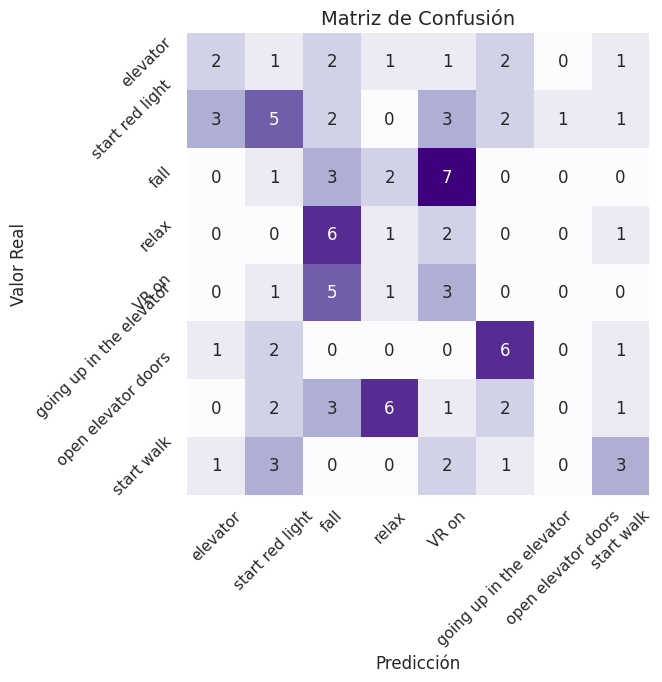


Cross-validation results for LogisticRegression:
Accuracy: 0.21052631578947367
Classification Report:
                          precision    recall  f1-score   support

                   VR on       0.50      0.10      0.17        10
                elevator       0.26      0.41      0.32        17
                    fall       0.19      0.38      0.25        13
going up in the elevator       0.00      0.00      0.00        10
     open elevator doors       0.00      0.00      0.00        10
                   relax       0.33      0.20      0.25        10
         start red light       0.09      0.13      0.11        15
              start walk       0.33      0.30      0.32        10

                accuracy                           0.21        95
               macro avg       0.21      0.19      0.18        95
            weighted avg       0.21      0.21      0.19        95



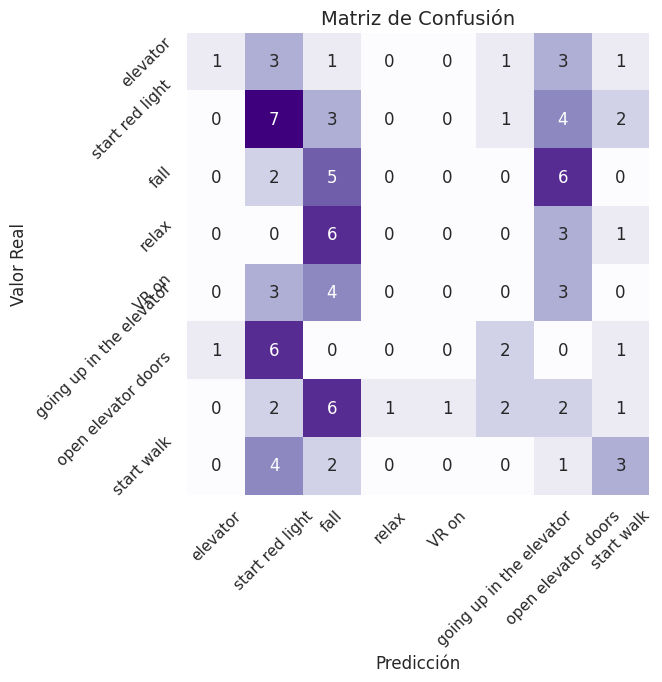


Cross-validation results for RandomForestClassifier:
Accuracy: 0.42105263157894735
Classification Report:
                          precision    recall  f1-score   support

                   VR on       0.25      0.20      0.22        10
                elevator       0.39      0.41      0.40        17
                    fall       0.33      0.38      0.36        13
going up in the elevator       0.60      0.60      0.60        10
     open elevator doors       0.30      0.30      0.30        10
                   relax       0.50      0.70      0.58        10
         start red light       0.55      0.40      0.46        15
              start walk       0.44      0.40      0.42        10

                accuracy                           0.42        95
               macro avg       0.42      0.42      0.42        95
            weighted avg       0.42      0.42      0.42        95



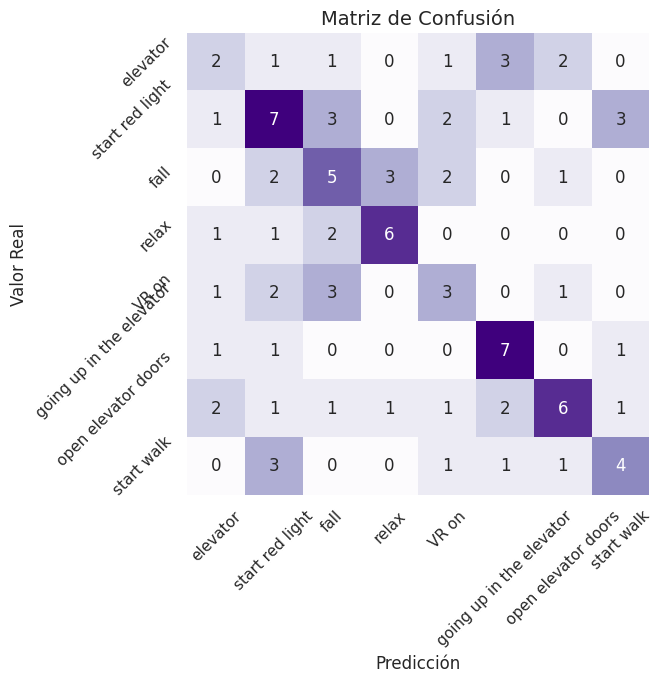


Cross-validation results for GradientBoostingClassifier:
Accuracy: 0.25263157894736843
Classification Report:
                          precision    recall  f1-score   support

                   VR on       0.11      0.10      0.11        10
                elevator       0.18      0.24      0.21        17
                    fall       0.10      0.08      0.09        13
going up in the elevator       0.67      0.40      0.50        10
     open elevator doors       0.18      0.20      0.19        10
                   relax       0.33      0.60      0.43        10
         start red light       0.25      0.20      0.22        15
              start walk       0.43      0.30      0.35        10

                accuracy                           0.25        95
               macro avg       0.28      0.26      0.26        95
            weighted avg       0.27      0.25      0.25        95



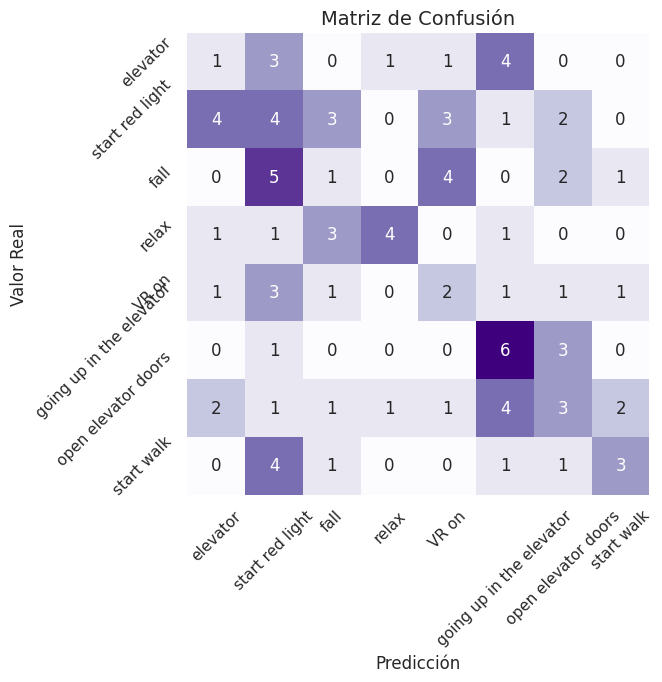


Cross-validation results for KNeighborsClassifier:
Accuracy: 0.30526315789473685
Classification Report:
                          precision    recall  f1-score   support

                   VR on       0.08      0.10      0.09        10
                elevator       0.22      0.29      0.25        17
                    fall       0.22      0.15      0.18        13
going up in the elevator       0.42      0.50      0.45        10
     open elevator doors       0.36      0.40      0.38        10
                   relax       0.31      0.40      0.35        10
         start red light       0.57      0.53      0.55        15
              start walk       0.00      0.00      0.00        10

                accuracy                           0.31        95
               macro avg       0.27      0.30      0.28        95
            weighted avg       0.28      0.31      0.29        95



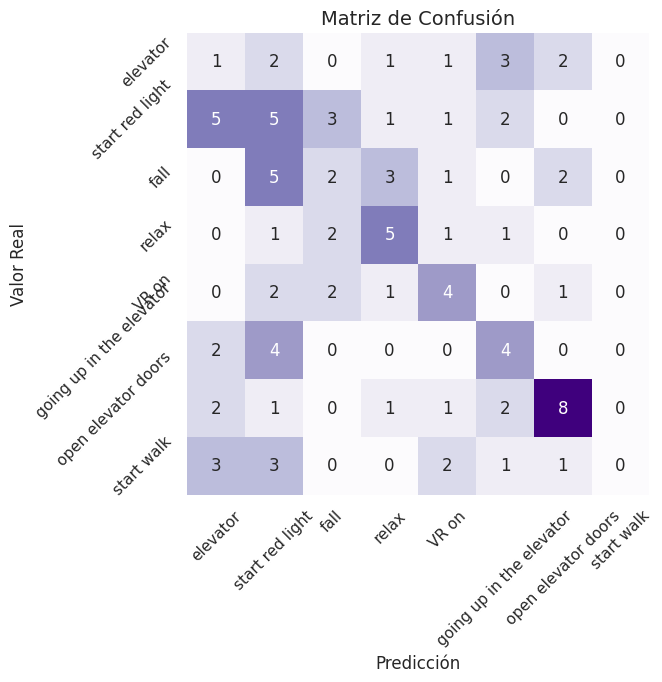


Cross-validation results for CatBoostClassifier:
Accuracy: 0.3368421052631579
Classification Report:
                          precision    recall  f1-score   support

                   VR on       0.38      0.30      0.33        10
                elevator       0.38      0.35      0.36        17
                    fall       0.16      0.23      0.19        13
going up in the elevator       0.56      0.50      0.53        10
     open elevator doors       0.00      0.00      0.00        10
                   relax       0.58      0.70      0.64        10
         start red light       0.29      0.27      0.28        15
              start walk       0.36      0.40      0.38        10

                accuracy                           0.34        95
               macro avg       0.34      0.34      0.34        95
            weighted avg       0.33      0.34      0.33        95



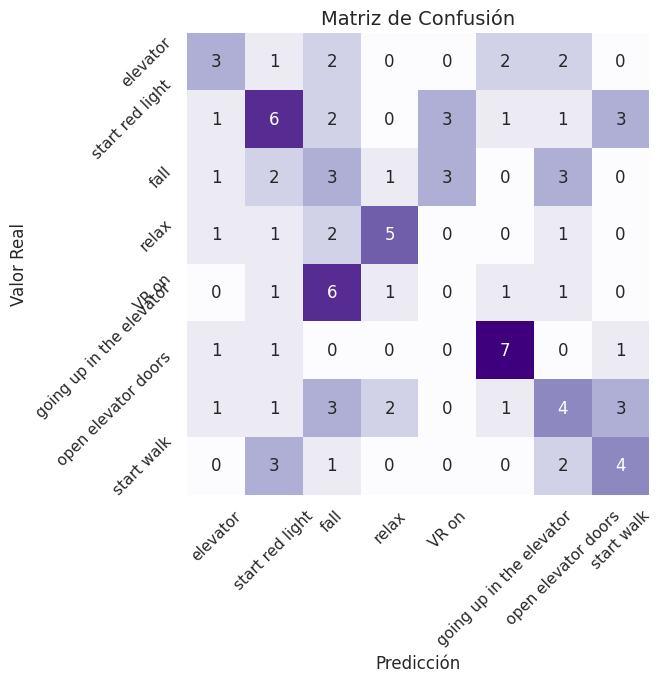

In [ ]:
df_caracteristicas_hrv = df_caracteristicas_hrv.dropna()
predictions = cross_validation_classification_models(df_caracteristicas_hrv, 10)

* El modelo de Random Forest obtuvo el mejor resultado con un accuracy de 42.1%. Si bien este valor no es alto, en muchos escenarios de clasificación complejos con múltiples clases, un 40-50% de precisión podría considerarse un valor aceptable.  "Relax" y "Going up in the elevator" tienen los mejores valores de recall (70% y 60%), lo que significa que estas situaciones generan respuestas fisiológicas más consistentes y distinguibles. "VR on", "Fall" y "Start red light" tienen un recall bajo, lo que sugiere que los patrones fisiológicos de HRV en estos casos pueden solaparse con otras situaciones o ser más variables.

* El modelo Naive Bayes muestra una precisión de solo 24.2%. Esto podría ser un reflejo de que las características no siguen una distribución normal, que es una de las principales suposiciones del Naive Bayes.

* La Logistic Regression también muestra un desempeño pobre con una precisión de 21.1%. Este modelo es sensible a las relaciones lineales entre las características.

* El Gradient Boosting obtuvo un accuracy de 25.3%, lo cual también es bajo.

* KNN tiene una precisión de 30.5%, que es ligeramente mejor que los anteriores, pero sigue siendo baja. KNN puede verse afectado por la calidad y la cantidad de las características, además de que es sensible a la escala de los datos.

* El CatBoost obtuvo un accuracy de 33.7%, este modelo usualmente requiere una mayor optimización de hiperparámetros.

**Posibles explicaciones del bajo rendimiento**

* Variabilidad en la respuesta fisiológica: No todas las personas reaccionan igual a las mismas situaciones en realidad virtual. Algunas pueden sentir miedo en el ascensor, mientras que otras no.
* Hay datos desbalanceados en el dataset, por lo que ocurre desbalance entre clases.

### **En esta sección se evalua el Fear Level**

In [ ]:
# Eliminar valores NaN
características = características_hrv.dropna()

# Separar variables predictoras (X) y variable objetivo (y)
X = características.drop(['Contexto', 'filename', 'Fear_Level', 'Miedo_Alto'], axis=1)
y = características['Fear_Level']

# Convertir X a valores numéricos (evitar problemas con mutual_info_classif)
X = X.apply(pd.to_numeric, errors='coerce')

# Calcular la importancia de las características usando mutual information
X_new = mutual_info_classif(X, y, discrete_features=False)

# Crear un DataFrame con la importancia de cada característica
feat_imp = pd.Series(X_new, index=X.columns).sort_values(ascending=False)

# Mostrar la importancia de cada característica
display(feat_imp)

# Seleccionar características con importancia mayor a un umbral (ajustable)
umbral_importancia = 0.01
feat_imp_sorted = feat_imp[feat_imp > umbral_importancia]

display(feat_imp_sorted)

X_selected = características_hrv[feat_imp_sorted.index]
df_caracteristicas_hrv = pd.concat([características_hrv[['filename']], X_selected, y], axis=1)

display(df_caracteristicas_hrv.head())

,0
Kurtosis,0.097054
Mode,0.059813
Skewness,0.039596
Median NNI,0.031758
NN50,0.025925
LF,0.022246
PEI,0.012226
CV,0.006060
Correlation,0.000000
Area Under Curve,0.000000


,0
Kurtosis,0.097054
Mode,0.059813
Skewness,0.039596
Median NNI,0.031758
NN50,0.025925
LF,0.022246
PEI,0.012226


,filename,Kurtosis,Mode,Skewness,Median NNI,NN50,LF,PEI,Fear_Level
1,mario.txt,4.023229,521,1.165853,520.0,1,0,0.118110,0.0
2,mario.txt,5.260293,521,1.556606,544.0,3,0,0.210526,1.0
4,mario.txt,2.498579,507,0.317791,519.0,0,0,0.000000,0.0
5,mario.txt,2.994650,488,1.025574,499.0,0,0,0.055556,1.0
6,luis.txt,5.137143,807,-0.311893,761.5,11,0,0.488095,0.0


In [ ]:
def cross_validation_classification_models(df, num_folds):

    models = {
        'Naive Bayes': GaussianNB(),
        'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs'),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=24),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'CatBoost': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)
    }

    predictions = {}  # Diccionario para almacenar las predicciones

    # Evaluamos el rendimiento de cada modelo
    for model_name, model in models.items():

        # Utilizamos cross_val_predict para obtener las predicciones
        from sklearn.model_selection import cross_val_predict

        X = df.drop(['Contexto', 'filename', 'Fear_Level'], axis=1, errors='ignore')
        y = df['Fear_Level']

        #
        if 'Tiempo_Acumulado' in X.columns:
            X = X.drop('Tiempo_Acumulado', axis=1)

        # Ajustar el modelo para obtener las clases
        model.fit(X, y)
        predicted = cross_val_predict(model, X, y, cv=num_folds)

        #  métricas
        print("Cross-validation results for {}:".format(model.__class__.__name__))
        print("Accuracy:", accuracy_score(y, predicted))
        print("Classification Report:")
        print(classification_report(y, predicted))

        # Matriz de confusión
        conf_mat = confusion_matrix(y, predicted)
        plt.figure(figsize=(8, 6))

        #
        sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Purples", cbar=False,
                    xticklabels=y.unique(), yticklabels=y.unique(),
                    annot_kws={"size": 12}, square=True)

        #
        plt.title("Matriz de Confusión", fontsize=14)
        plt.xlabel("Predicción", fontsize=12)
        plt.ylabel("Valor Real", fontsize=12)

        #
        plt.xticks(rotation=45)
        plt.yticks(rotation=45)
        plt.show()
        print()

        #
        predictions[model_name] = {
            'real': y,
            'predicted': predicted
        }

    return predictions

Cross-validation results for GaussianNB:
Accuracy: 0.5106382978723404
Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.71      0.74        65
         1.0       0.00      0.00      0.00         8
         2.0       0.00      0.00      0.00         9
         3.0       0.00      0.00      0.00         4
         4.0       0.10      0.29      0.14         7
         5.0       0.00      0.00      0.00         1

    accuracy                           0.51        94
   macro avg       0.15      0.17      0.15        94
weighted avg       0.55      0.51      0.52        94



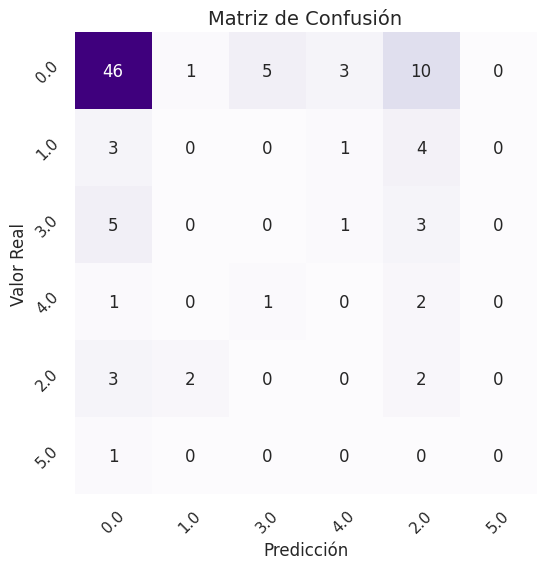


Cross-validation results for LogisticRegression:
Accuracy: 0.648936170212766
Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.94      0.80        65
         1.0       0.00      0.00      0.00         8
         2.0       0.00      0.00      0.00         9
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         7
         5.0       0.00      0.00      0.00         1

    accuracy                           0.65        94
   macro avg       0.12      0.16      0.13        94
weighted avg       0.48      0.65      0.55        94



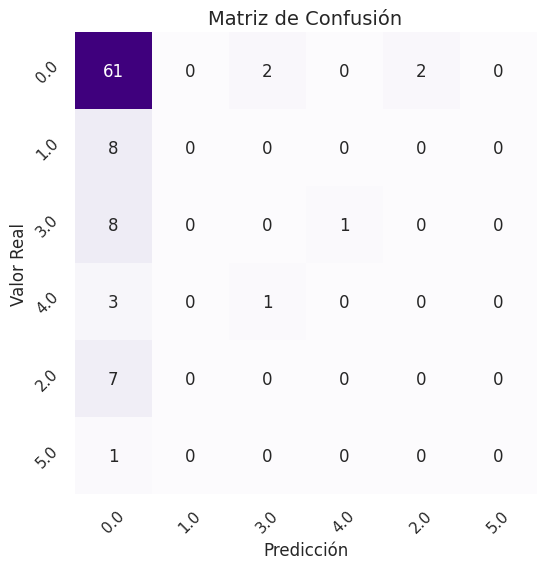


Cross-validation results for RandomForestClassifier:
Accuracy: 0.6276595744680851
Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.88      0.79        65
         1.0       0.22      0.25      0.24         8
         2.0       0.00      0.00      0.00         9
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         7
         5.0       0.00      0.00      0.00         1

    accuracy                           0.63        94
   macro avg       0.16      0.19      0.17        94
weighted avg       0.52      0.63      0.57        94



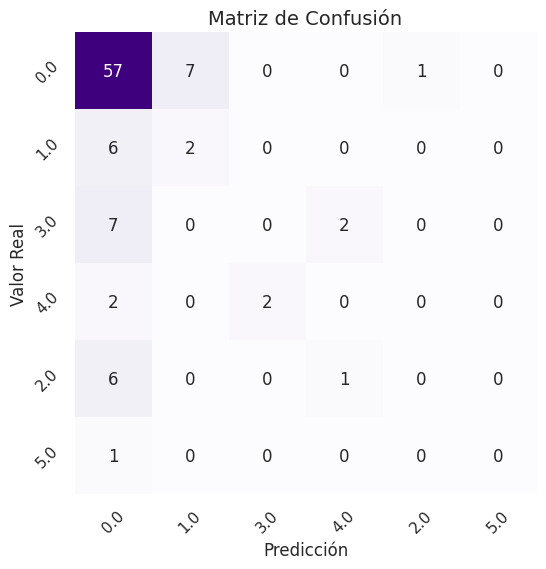


Cross-validation results for GradientBoostingClassifier:
Accuracy: 0.6276595744680851
Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.85      0.80        65
         1.0       0.20      0.12      0.15         8
         2.0       0.50      0.33      0.40         9
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         7
         5.0       0.00      0.00      0.00         1

    accuracy                           0.63        94
   macro avg       0.24      0.22      0.23        94
weighted avg       0.59      0.63      0.60        94



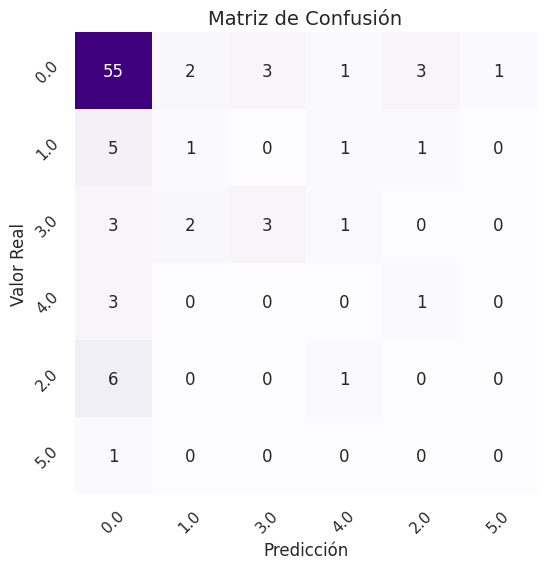


Cross-validation results for KNeighborsClassifier:
Accuracy: 0.6276595744680851
Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      0.91      0.78        65
         1.0       0.00      0.00      0.00         8
         2.0       0.00      0.00      0.00         9
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         7
         5.0       0.00      0.00      0.00         1

    accuracy                           0.63        94
   macro avg       0.11      0.15      0.13        94
weighted avg       0.47      0.63      0.54        94



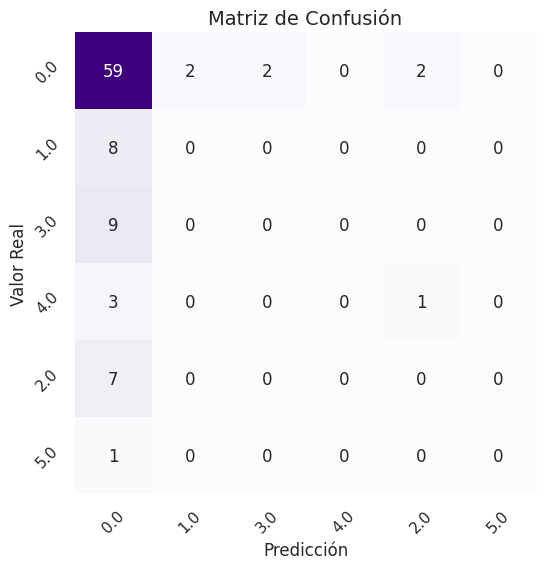


Cross-validation results for CatBoostClassifier:
Accuracy: 0.6702127659574468
Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.94      0.80        65
         1.0       0.40      0.25      0.31         8
         2.0       0.00      0.00      0.00         9
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         7
         5.0       0.00      0.00      0.00         1

    accuracy                           0.67        94
   macro avg       0.18      0.20      0.19        94
weighted avg       0.52      0.67      0.58        94



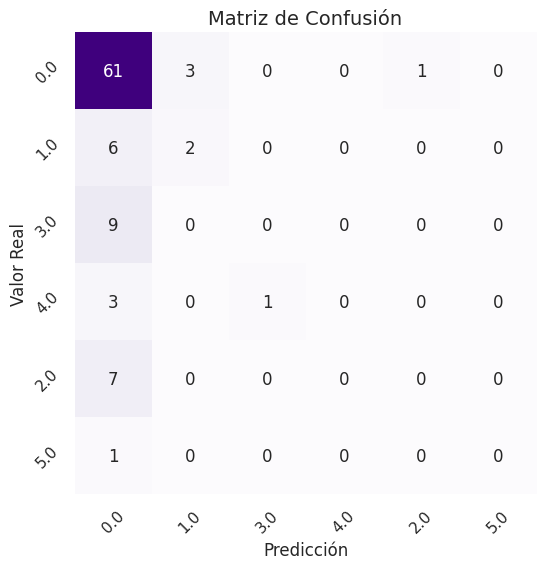

In [ ]:
df_caracteristicas_hrv = df_caracteristicas_hrv.dropna()
predictions = cross_validation_classification_models(df_caracteristicas_hrv, 10)

Se ha realizado la clasificación del nivel de miedo, medido en una escala de 0 a 5, utilizando distintos modelos de clasificación. Los resultados obtenidos en los modelos fueron los siguientes:

* El rendimiento del modelo de Naive Bayes es moderado, con una precisión de 51.1%. Sin embargo, no se muestra un buen desempeño en las clases más altas de miedo (por ejemplo, los niveles 3, 4 y 5). La regresión logística muestra una mejora considerable en comparación con Naive Bayes, alcanzando una precisión de 64.9%. Este modelo tiene un mejor desempeño general, especialmente en los niveles de miedo más bajos (por ejemplo, nivel 0).

* El modelo Random Forest tiene una precisión similar a la de la regresión logística, con 62.8%. Sin embargo, su performance es desbalanceado ya que muestra un buen desempeño en las clases más bajas (nivel 0), pero tiene una capacidad nula para predecir las clases más altas (niveles 2 a 5).  Al igual que el Random Forest, el modelo de Gradient Boosting tiene un rendimiento similar, con una precisión del 62.8%. El modelo KNN también muestra un rendimiento similar al de Random Forest y Gradient Boosting, con una precisión de 62.8%.

* El modelo CatBoost logra el mejor desempeño con una precisión de 67.0%. A pesar de ser el modelo más preciso, muestra el mismo patrón que los modelos anteriores, con buenos resultados para la clase 0 (bajo miedo), pero una incapacidad para predecir correctamente los niveles más altos de miedo (2 a 5).

* Posibles problemas:

Un patrón común en todos los modelos es que el desempeño es bueno en la clase 0 (sin miedo) pero se degrada notablemente cuando se trata de los niveles más altos de miedo (2 a 5). Esto probablemente se debe a un desbalance de clases, donde los niveles de miedo más bajos tienen muchas más instancias que los niveles altos.

### **En esta sección se evalua el Fear Level por asignación binaria**

In [88]:
# Crear una nueva columna binaria para Fear_Level
características['Fear_Binary'] = características['Fear_Level'].apply(lambda x: 1 if x >= 3 else 0)

# Eliminar filas con NaN en las columnas relevantes para X e y
características = características.dropna(subset=['Fear_Binary', 'Fear_Level'])

# Separar variables predictoras (X) y variable objetivo (y)
X = características.drop(['Contexto', 'filename', 'Fear_Level', 'Fear_Binary'], axis=1)
y = características['Fear_Binary']

X = X.dropna()
y = y[X.index]

X = X.apply(pd.to_numeric, errors='coerce')

X_new = mutual_info_classif(X, y, discrete_features=False)

# DataFrame con la importancia de cada característica
feat_imp = pd.Series(X_new, index=X.columns).sort_values(ascending=False)


display(feat_imp)
umbral_importancia = 0.01
feat_imp_sorted = feat_imp[feat_imp > umbral_importancia]

display(feat_imp_sorted)

# Crear un nuevo DataFrame con las características seleccionadas
X_selected = características[feat_imp_sorted.index]
df_caracteristicas_hrv = pd.concat([características[['filename']], X_selected, y], axis=1)

X_selected = X_selected.dropna()
y = y[X_selected.index]

assert X_selected.shape[0] == len(y), f"Mismatch in number of samples: X={X_selected.shape[0]}, y={len(y)}"
display(df_caracteristicas_hrv.head())

,0
Mode,0.046306
Median NNI,0.044338
PEI,0.031199
Range NNI,0.024880
SD2,0.023740
NN50,0.023215
LF,0.012806
HF,0.002902
Shannon Entropy,0.000760
CV,0.000000


,0
Mode,0.046306
Median NNI,0.044338
PEI,0.031199
Range NNI,0.024880
SD2,0.023740
NN50,0.023215
LF,0.012806


,filename,Mode,Median NNI,PEI,Range NNI,SD2,NN50,LF,Fear_Binary
1,mario.txt,521,520.0,0.118110,156.0,14.045813,1,0,0
2,mario.txt,521,544.0,0.210526,193.0,24.160025,3,0,0
4,mario.txt,507,519.0,0.000000,85.0,8.387383,0,0,0
5,mario.txt,488,499.0,0.055556,113.0,13.456871,0,0,0
6,luis.txt,807,761.5,0.488095,499.0,124.246093,11,0,0


In [91]:
def cross_validation_classification_models(df, num_folds):

    models = {
        'Naive Bayes': GaussianNB(),
        'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs'),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=24),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'CatBoost': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)
    }

    predictions = {}  #

    # Evaluamos el rendimiento de cada modelo
    for model_name, model in models.items():

        # Utilizamos cross_val_predict para obtener las predicciones
        from sklearn.model_selection import cross_val_predict

        # Reset index to avoid issues with mismatched indices during splitting
        df = df.reset_index(drop=True)

        X = df.drop(['Contexto', 'filename', 'Fear_Binary'], axis=1, errors='ignore')
        y = df['Fear_Binary'].values.ravel()

        if 'Tiempo_Acumulado' in X.columns:
            X = X.drop('Tiempo_Acumulado', axis=1)

        # Ajustar el modelo para obtener las clases
        model.fit(X, y)
        predicted = cross_val_predict(model, X, y, cv=num_folds)

        # métricas
        print("Cross-validation results for {}:".format(model.__class__.__name__))
        print("Accuracy:", accuracy_score(y, predicted))
        print("Classification Report:")
        print(classification_report(y, predicted))

        # Matriz de confusión
        conf_mat = confusion_matrix(y, predicted)
        plt.figure(figsize=(8, 6))
        unique_y = df['Fear_Binary'].unique()

        # heatmap
        sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Purples", cbar=False,
                    xticklabels=unique_y, yticklabels=unique_y,
                    annot_kws={"size": 12}, square=True)

        plt.title("Matriz de Confusión", fontsize=14)
        plt.xlabel("Predicción", fontsize=12)
        plt.ylabel("Valor Real", fontsize=12)

        plt.xticks(rotation=45)
        plt.yticks(rotation=45)
        plt.show()
        print()

        predictions[model_name] = {
            'real': y,
            'predicted': predicted
        }

    return predictions

Cross-validation results for GaussianNB:
Accuracy: 0.723404255319149
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83        82
           1       0.21      0.42      0.28        12

    accuracy                           0.72        94
   macro avg       0.55      0.59      0.55        94
weighted avg       0.81      0.72      0.76        94



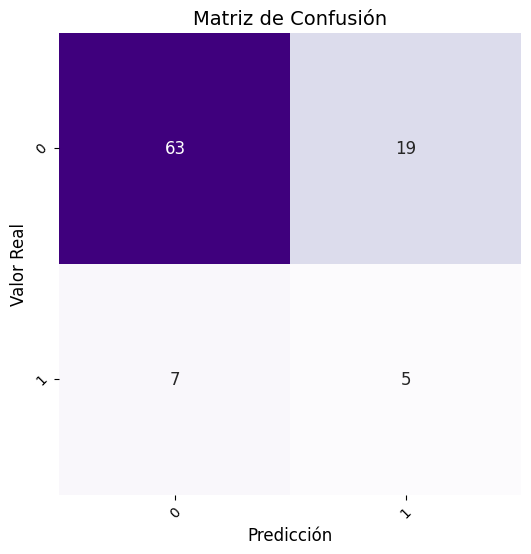


Cross-validation results for LogisticRegression:
Accuracy: 0.8404255319148937
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91        82
           1       0.00      0.00      0.00        12

    accuracy                           0.84        94
   macro avg       0.43      0.48      0.46        94
weighted avg       0.76      0.84      0.80        94



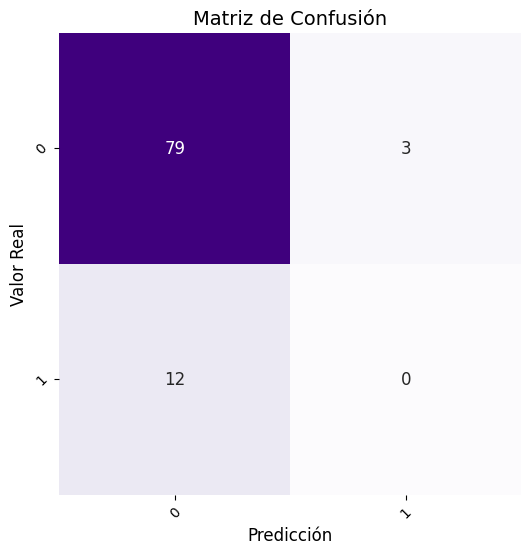


Cross-validation results for RandomForestClassifier:
Accuracy: 0.8723404255319149
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93        82
           1       0.50      0.08      0.14        12

    accuracy                           0.87        94
   macro avg       0.69      0.54      0.54        94
weighted avg       0.83      0.87      0.83        94



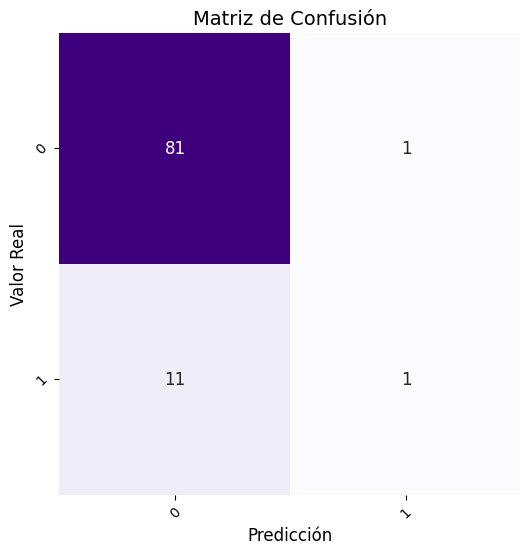


Cross-validation results for GradientBoostingClassifier:
Accuracy: 0.7978723404255319
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88        82
           1       0.18      0.17      0.17        12

    accuracy                           0.80        94
   macro avg       0.53      0.53      0.53        94
weighted avg       0.79      0.80      0.79        94



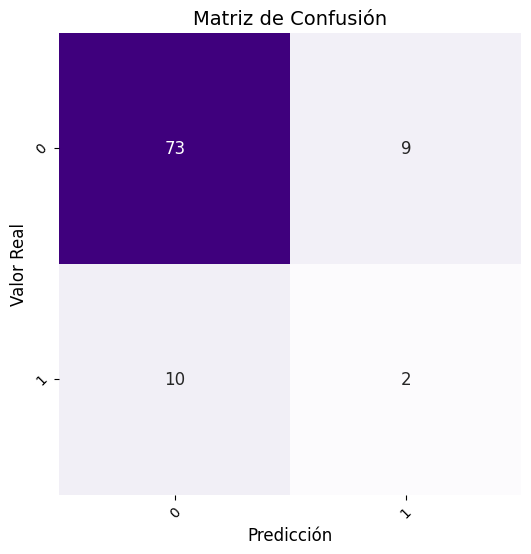


Cross-validation results for KNeighborsClassifier:
Accuracy: 0.8617021276595744
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92        82
           1       0.33      0.08      0.13        12

    accuracy                           0.86        94
   macro avg       0.61      0.53      0.53        94
weighted avg       0.81      0.86      0.82        94



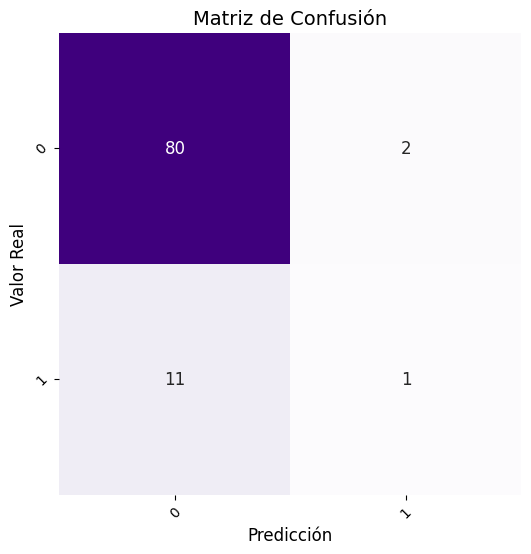


Cross-validation results for CatBoostClassifier:
Accuracy: 0.8617021276595744
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92        82
           1       0.33      0.08      0.13        12

    accuracy                           0.86        94
   macro avg       0.61      0.53      0.53        94
weighted avg       0.81      0.86      0.82        94



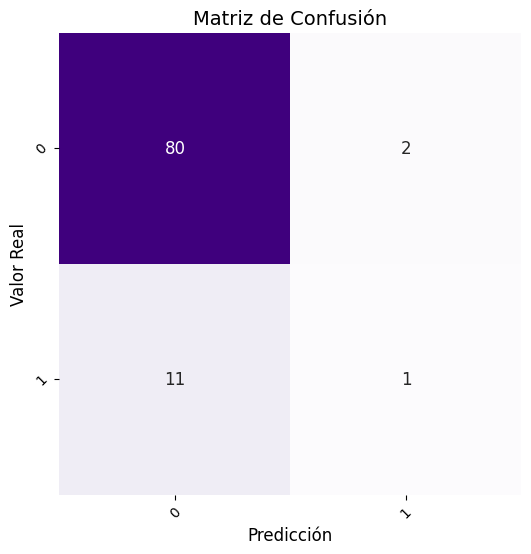

In [94]:
df_caracteristicas_hrv = df_caracteristicas_hrv.dropna()
predictions = cross_validation_classification_models(df_caracteristicas_hrv, 10)

En esta sección, el nivel de miedo de las personas se clasificó de manera binaria, asignando un valor de 0 para niveles de miedo bajos (menores a 3) y un valor de 1 para niveles de miedo altos (3 o más). Esta clasificación binaria se utilizó como objetivo de la variable para entrenar y evaluar varios modelos de clasificación, con el objetivo de predecir si una persona experimenta un nivel alto de miedo (1) o bajo (0) a partir de las características fisiológicas obtenidas.

Los resultados obtenidos fueron los siguientes:

* El modelo de Naive Bayes alcanzó una precisión del 72.3%. Aunque la precisión general es relativamente buena, el modelo presenta un rendimiento subóptimo en la clase 1 (miedo alto), con recall y f1-score cercanos a cero. Esto sugiere que el modelo no está capturando adecuadamente las instancias con miedo alto, probablemente debido a un desbalance de clases.

* La regresión logística mostró un buen desempeño, alcanzando una precisión del 84.0%. Sin embargo, aunque la precisión es alta, el modelo sigue teniendo dificultades con la clase 1 (miedo alto).

* Random Forest mostró el mejor desempeño en términos de precisión, con un 87.2%. Aunque la precisión es alta, el modelo presenta una notable desventaja al clasificar la clase 1 (miedo alto), con una recall de solo 8%. Esto indica que, aunque el modelo es efectivo para identificar los casos de miedo bajo, falla en predecir correctamente los casos de miedo alto.

* Gradient Boosting presentó una precisión del 79.8%. Aunque mostró un rendimiento razonable, especialmente en la clase 0, la capacidad para predecir la clase 1 fue deficiente. El modelo KNN tuvo una precisión similar a la de Random Forest y CatBoost, con un 86.2%. A pesar de ser bastante preciso en la clasificación de la clase 0, su desempeño en la clase 1 es bajo, con una recall del 8%.  CatBoost también mostró un rendimiento similar al de KNN, con una precisión del 86.2%. El modelo, aunque efectivo en clasificar la clase 0, también presenta limitaciones en la predicción de la clase 1, con una baja recall para la clase de miedo alto.

**Posibles problemas**

Un patrón común entre todos los modelos es que la clase 0 (miedo bajo) tiene un mayor número de muestras en comparación con la clase 1 (miedo alto). Esto provoca que los modelos estén sesgados hacia la clase 0, resultando en un rendimiento pobre para la clase 1.

La clasificación binaria del nivel de miedo mostró que, aunque los modelos alcanzaron una buena precisión general, su capacidad para predecir los casos de miedo alto (clase 1) es limitada. La principal causa de este desafío es el desbalance de clases, que hace que los modelos estén más enfocados en predecir correctamente la clase 0 (miedo bajo).



### **Conclusión**

En esta práctica se analizaron los datos fisiológicos de un grupo de participantes que fueron expuestos a un entorno virtual diseñado para inducir miedo y vértigo. Para ello, se capturó la variabilidad de la frecuencia cardíaca (HRV) mediante un sensor colocado en el esternón, y los datos se segmentaron utilizando videos de los participantes durante la exposición. El objetivo principal fue construir modelos de clasificación capaces de distinguir entre los diferentes contextos del entorno virtual y clasificar el nivel de miedo experimentado por los participantes.

Se utilizaron varios modelos de clasificación para predecir los diferentes contextos experimentados por los participantes. Sin embargo, los resultados mostraron una exactitud baja en la clasificación por evento, con el modelo RandomForest obteniendo una precisión del 42.1%. A pesar de que RandomForest es un modelo robusto, presentó dificultades al intentar clasificar correctamente los escenarios en múltiples clases.

Debido a los problemas en la clasificación de escenarios, se optó por una clasificación del miedo en una escala de 0 a 5, donde 0 representa el miedo más bajo y 5 el miedo más alto. En este escenario, el modelo CatBoost se destacó como el mejor, con una exactitud de 67.0%. Sin embargo, aunque CatBoost mostró el mejor rendimiento en términos de precisión, todos los modelos enfrentaron el mismo desbalance de clases. Los modelos tendieron a predecir correctamente los niveles de miedo bajos (nivel 0), pero tuvieron dificultades al intentar predecir los niveles más altos de miedo.

Dado que los modelos tuvieron dificultades para clasificar correctamente los niveles más altos de miedo, se procedió a realizar una clasificación binaria del miedo. Los niveles de miedo bajos (menores a 3) fueron asignados al valor 0, y los niveles de miedo altos (3 o más) al valor 1. Los resultados de la clasificación binaria del miedo mostraron que, aunque los modelos lograron una buena precisión general, su capacidad para predecir los casos de miedo alto (clase 1) fue limitada. Este desafío se debe en gran medida al desbalance de clases, lo que provoca que los modelos estén más enfocados en predecir correctamente la clase 0 (miedo bajo), mientras que los casos de miedo alto (clase 1) son menos frecuentes y más difíciles de predecir.

Se necesitan fururas investigaciones para explorar extrategias que mejoren la generalización de modelos de clasificación en diferentes contextos y clasificación de alguna emoción. Así mismo, todos los modelos enfrentaron un el desbalance de clases de eventos y niveles de miedo. Otro factor importante es que no todas las personas reaccionan de la misma manera ante situaciones en realidad virtual. Esta variabilidad en las respuestas individuales complicó la tarea de los modelos para generalizar correctamente las predicciones en todos los participantes.